### Data Visualization

Dataset shape after removing duplicates:
(43362, 3)

Number of genotypes:
10

Genotypes:
['1a', '1b', '2a', '2b', '2c', '3a', '3b', '4', '5', '6']


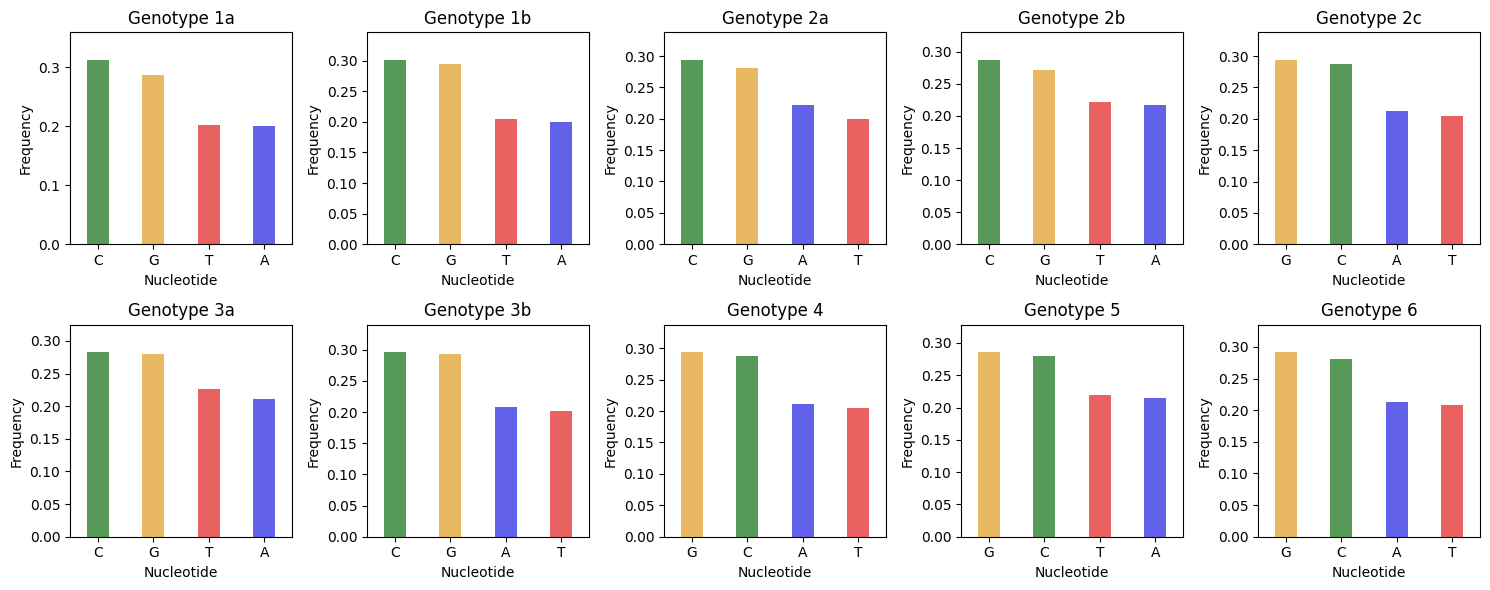

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# ============================================================
# Function to calculate nucleotide frequencies
# ============================================================
def calculate_nucleotide_frequencies(sequence):
    """
    Calculate the frequency of A, T, C, and G in a DNA sequence.
    """

    nucleotide_counts = {
        'A': 0,
        'T': 0,
        'C': 0,
        'G': 0
    }

    # Make sure sequence is a string and uppercase
    sequence = str(sequence).upper()

    for nucleotide in sequence:
        if nucleotide in nucleotide_counts:
            nucleotide_counts[nucleotide] += 1

    total_length = len(sequence)

    # Avoid division by zero for empty sequences
    if total_length == 0:
        return {
            'A': 0,
            'T': 0,
            'C': 0,
            'G': 0
        }

    nucleotide_frequencies = {
        nucleotide: count / total_length
        for nucleotide, count in nucleotide_counts.items()
    }

    return nucleotide_frequencies


# ============================================================
# Function to calculate average nucleotide frequencies
# ============================================================
def average_nucleotides(list_of_dicts):
    """
    Calculate the average nucleotide frequencies
    for a list of sequences belonging to one genotype.
    """

    average_counts = {
        'A': 0,
        'C': 0,
        'G': 0,
        'T': 0
    }

    # Avoid division by zero
    if len(list_of_dicts) == 0:
        return average_counts

    # Sum the frequencies
    for d in list_of_dicts:
        for nucleotide in average_counts:
            average_counts[nucleotide] += d[nucleotide]

    # Number of sequences
    num_dicts = len(list_of_dicts)

    # Calculate average
    for nucleotide in average_counts:
        average_counts[nucleotide] /= num_dicts

    return average_counts


# ============================================================
# Load dataset
# ============================================================
dataset = pd.read_csv('data.csv')


# ============================================================
# Remove duplicate sequences
# ============================================================
dataset.drop_duplicates(
    subset='seq',
    inplace=True
)

dataset.reset_index(
    drop=True,
    inplace=True
)


# ============================================================
# Display dataset shape
# ============================================================
print("Dataset shape after removing duplicates:")
print(dataset.shape)


# ============================================================
# Copy dataset
# ============================================================
df = dataset.copy()


# ============================================================
# Calculate nucleotide frequencies for every sequence
# ============================================================
df['nucleotide_frequencies'] = df['seq'].apply(
    calculate_nucleotide_frequencies
)


# ============================================================
# Get unique genotypes
# ============================================================
# sorted() ensures the genotype order is consistent
unique_genotypes = sorted(
    df['genotype'].dropna().unique()
)

print("\nNumber of genotypes:")
print(len(unique_genotypes))

print("\nGenotypes:")
print(unique_genotypes)


# ============================================================
# Calculate average nucleotide frequency for each genotype
# ============================================================
nuc_ratio = []

for genotype in unique_genotypes:

    genotype_frequencies = df.loc[
        df['genotype'] == genotype,
        'nucleotide_frequencies'
    ].tolist()

    average_frequency = average_nucleotides(
        genotype_frequencies
    )

    nuc_ratio.append(
        average_frequency
    )


# ============================================================
# Plot settings
# ============================================================

# Number of plots per row
plots_per_row = 5

# Number of rows needed
num_rows = int(
    np.ceil(
        len(unique_genotypes) / plots_per_row
    )
)


# ============================================================
# Define colors for nucleotides
# ============================================================
nucleotide_colors = {
    'A': 'blue',
    'C': 'green',
    'G': 'orange',
    'T': 'red'
}


# ============================================================
# Create figure
# ============================================================
fig, axs = plt.subplots(
    num_rows,
    plots_per_row,
    figsize=(15, 3 * num_rows)
)


# Ensure axs is always an array
axs = np.atleast_1d(axs).flatten()


# Bar width
bar_width = 0.4


# ============================================================
# Plot nucleotide frequencies for each genotype
# ============================================================
for i, (genotype, nucleotide_frequencies) in enumerate(
    zip(unique_genotypes, nuc_ratio)
):

    # Convert dictionary to DataFrame
    frequencies_df = pd.DataFrame({
        'Nucleotide': list(
            nucleotide_frequencies.keys()
        ),
        'Frequency': list(
            nucleotide_frequencies.values()
        )
    })

    # Sort nucleotides by frequency
    frequencies_df = frequencies_df.sort_values(
        by='Frequency',
        ascending=False
    )

    # Current subplot
    ax = axs[i]

    # --------------------------------------------------------
    # Updated Seaborn syntax
    #
    # hue='Nucleotide' is added because newer Seaborn versions
    # deprecate using palette without hue.
    # --------------------------------------------------------
    sns.barplot(
        data=frequencies_df,
        x='Nucleotide',
        y='Frequency',
        hue='Nucleotide',
        palette=nucleotide_colors,
        legend=False,
        ax=ax,
        saturation=0.75,
        errorbar=None,
        alpha=0.7,
        linewidth=0,
        width=bar_width
    )

    # Plot title
    ax.set_title(
        f'Genotype {genotype}'
    )

    # Axis labels
    ax.set_xlabel(
        'Nucleotide'
    )

    ax.set_ylabel(
        'Frequency'
    )

    # Since frequencies are proportions
    ax.set_ylim(
        0,
        max(
            frequencies_df['Frequency'].max() * 1.15,
            0.01
        )
    )


# ============================================================
# Remove unused subplots
# ============================================================
for i in range(
    len(unique_genotypes),
    len(axs)
):
    fig.delaxes(
        axs[i]
    )


# ============================================================
# Adjust layout
# ============================================================
plt.tight_layout()


# ============================================================
# Display plots
# ============================================================
plt.show()

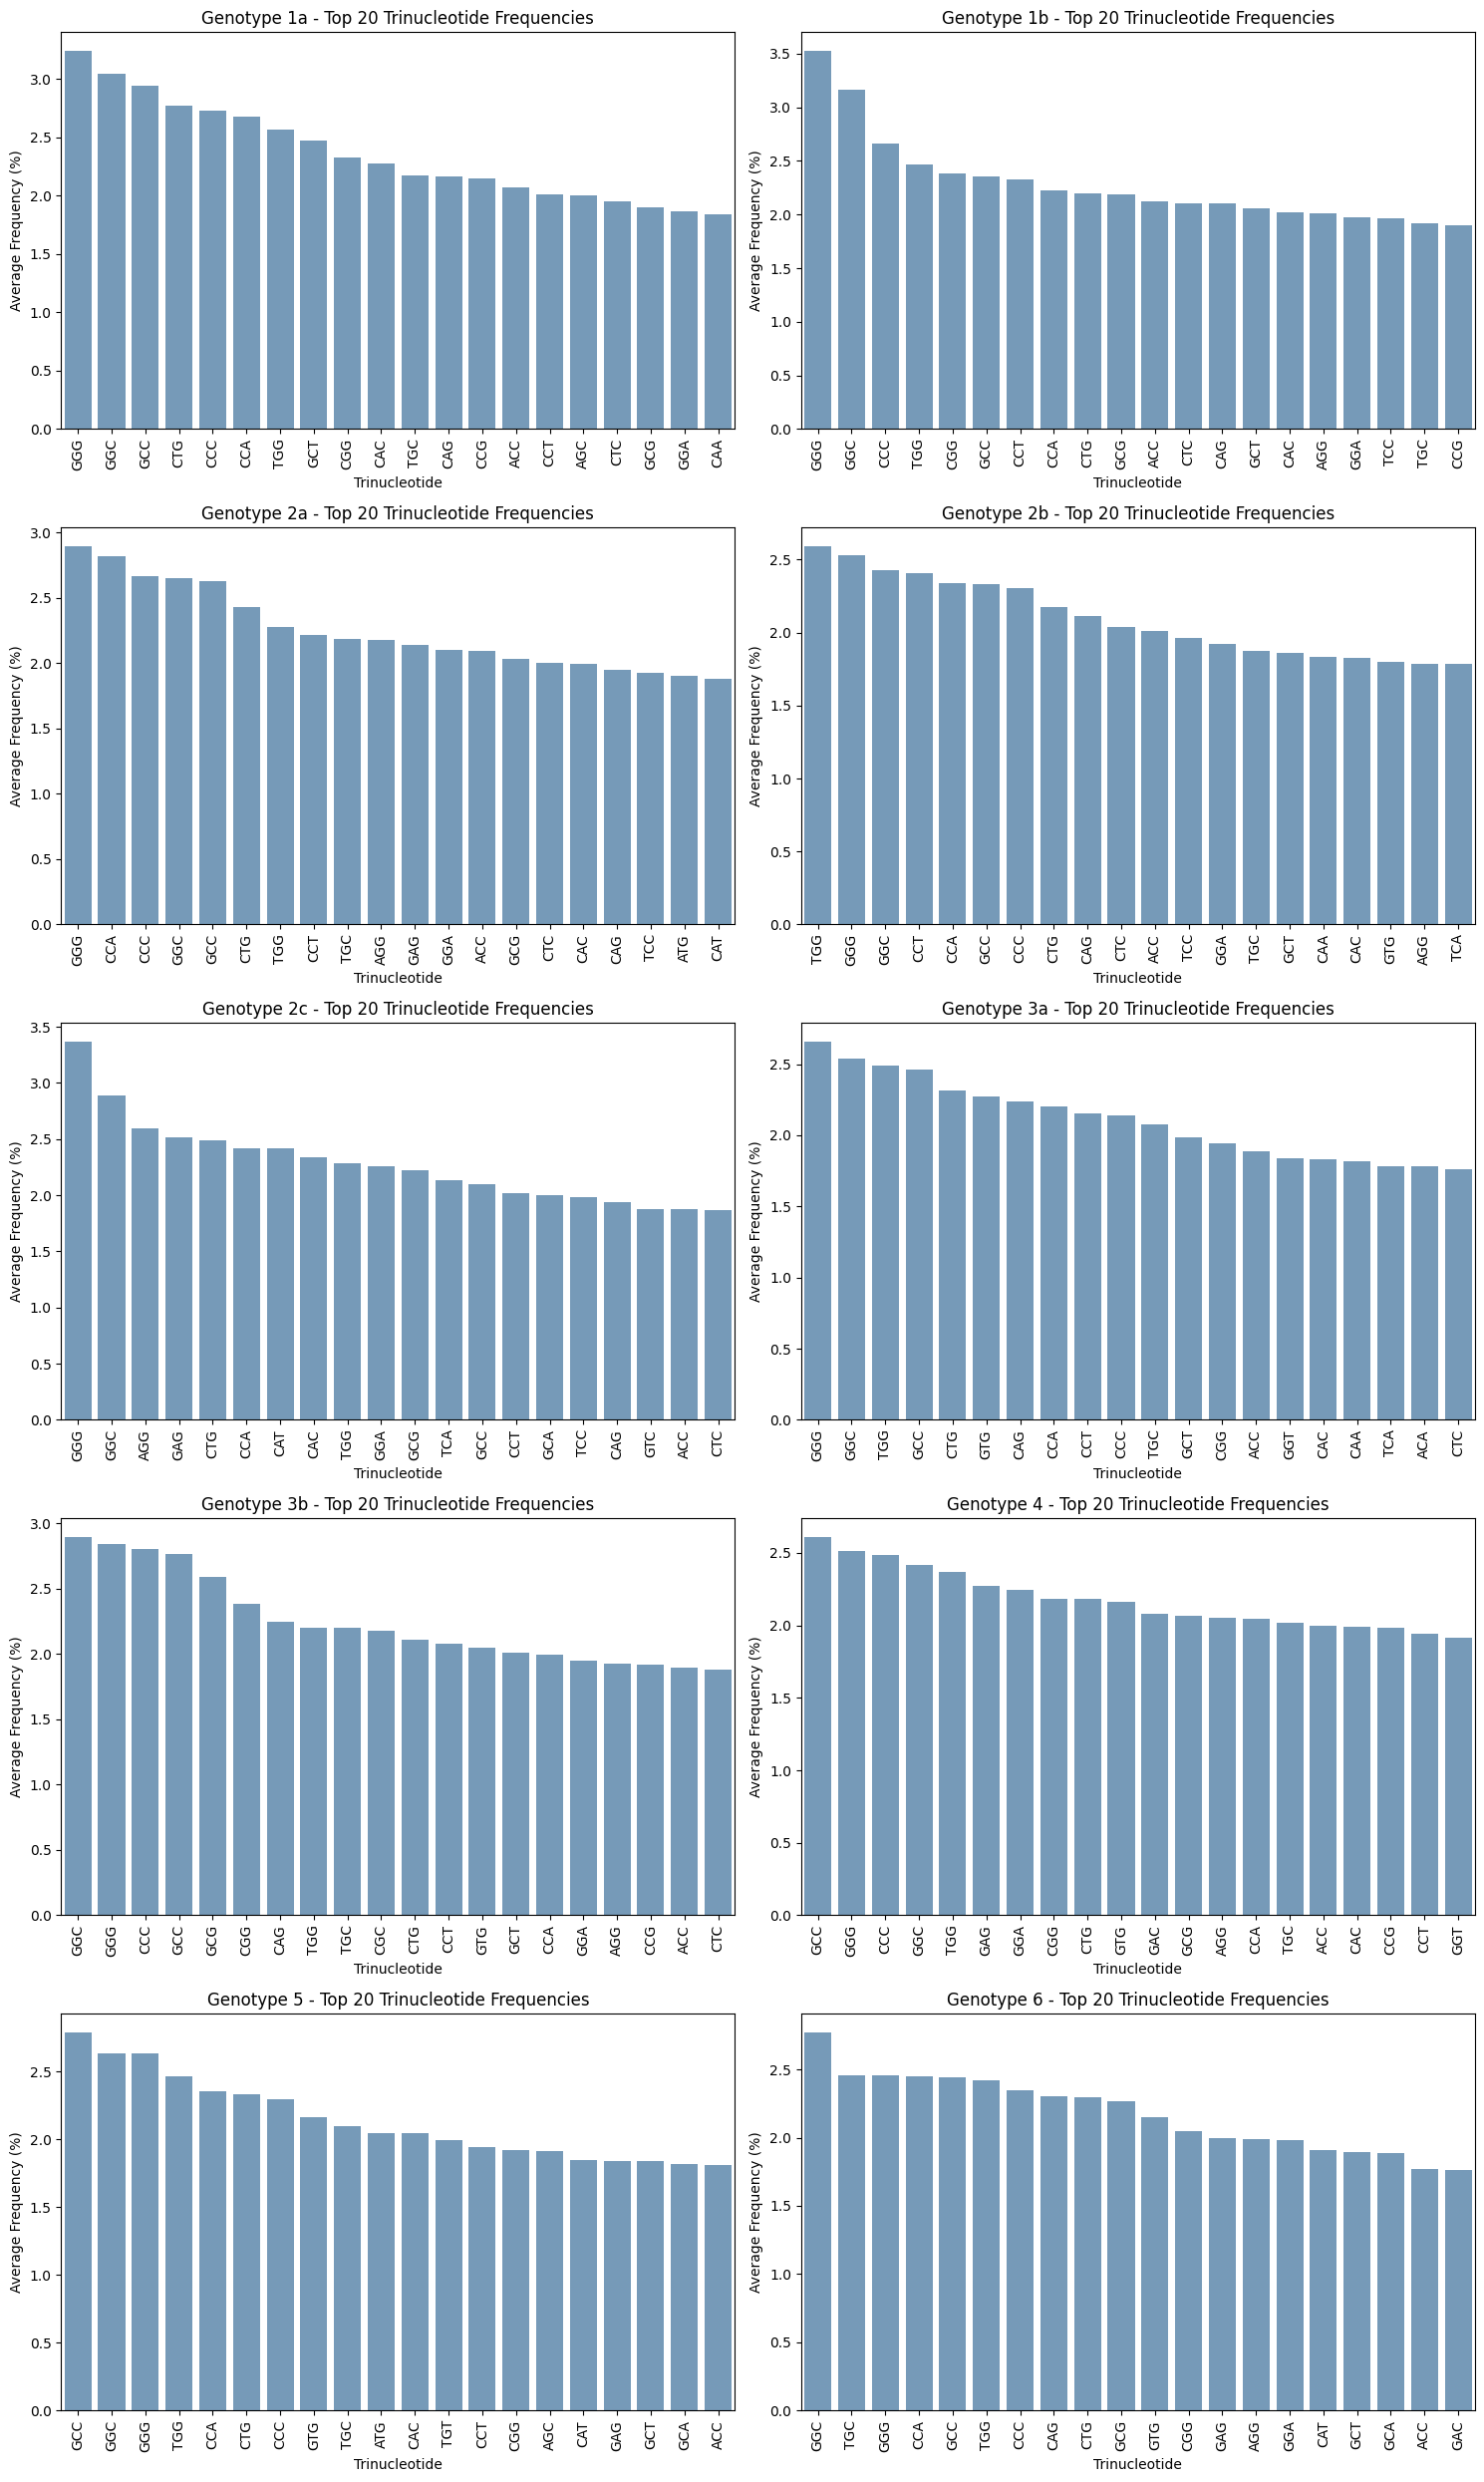

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Function to calculate trinucleotide frequencies
def calculate_trinucleotide_frequencies(sequence):
    trinucleotide_counts = {}

    # Make sure the sequence is a string and uppercase
    sequence = str(sequence).upper()

    for i in range(len(sequence) - 2):
        trinucleotide = sequence[i:i+3]

        if trinucleotide in trinucleotide_counts:
            trinucleotide_counts[trinucleotide] += 1
        else:
            trinucleotide_counts[trinucleotide] = 1

    total_count = sum(trinucleotide_counts.values())

    # Avoid division by zero
    if total_count == 0:
        return {}

    trinucleotide_frequencies = {
        trinucleotide: count / total_count
        for trinucleotide, count in trinucleotide_counts.items()
    }

    return trinucleotide_frequencies


# Copy dataset
df = dataset.copy()


# Calculate trinucleotide frequencies for each sequence
df['trinucleotide_frequencies'] = df['seq'].apply(
    calculate_trinucleotide_frequencies
)


# Get unique genotypes
unique_genotypes = df['genotype'].unique()


# Number of plots per row
plots_per_row = 2


# Calculate number of rows
num_rows = (
    len(unique_genotypes) // plots_per_row
    + (len(unique_genotypes) % plots_per_row > 0)
)


# Create subplots
fig, axs = plt.subplots(
    num_rows,
    plots_per_row,
    figsize=(15, 5 * num_rows),
    squeeze=False
)


# Number of top trinucleotides to display
TOP_N = 20


# Loop through each genotype
for i, genotype in enumerate(unique_genotypes):

    row = i // plots_per_row
    col = i % plots_per_row

    # Select sequences belonging to this genotype
    genotype_df = df[df['genotype'] == genotype]


    # Accumulate frequencies
    total_frequencies = {}

    for frequencies in genotype_df['trinucleotide_frequencies']:

        for trinucleotide, frequency in frequencies.items():

            if trinucleotide in total_frequencies:
                total_frequencies[trinucleotide] += frequency
            else:
                total_frequencies[trinucleotide] = frequency


    # Number of sequences in this genotype
    num_sequences = len(genotype_df)


    # Calculate average frequency as a percentage
    average_frequencies_percentage = {
        trinucleotide: (total_frequency / num_sequences) * 100
        for trinucleotide, total_frequency in total_frequencies.items()
    }


    # Sort by average percentage and select top N
    sorted_frequencies = dict(
        sorted(
            average_frequencies_percentage.items(),
            key=lambda item: item[1],
            reverse=True
        )[:TOP_N]
    )


    # Convert to DataFrame
    frequencies_df = pd.DataFrame({
        'Trinucleotide': list(sorted_frequencies.keys()),
        'Average Frequency (%)': list(sorted_frequencies.values())
    })


    # Select subplot
    ax = axs[row, col]


    # Plot with one blue color
    sns.barplot(
        data=frequencies_df,
        x='Trinucleotide',
        y='Average Frequency (%)',
        color='steelblue',
        ax=ax,
        errorbar=None,
        saturation=0.75,
        alpha=0.8,
        linewidth=0,
        width=0.8
    )


    # Title and labels
    ax.set_title(
        f'Genotype {genotype} - Top {TOP_N} Trinucleotide Frequencies'
    )

    ax.set_xlabel('Trinucleotide')
    ax.set_ylabel('Average Frequency (%)')


    # Rotate x-axis labels
    ax.tick_params(
        axis='x',
        labelrotation=90
    )


# Remove unused subplots
for i in range(
    len(unique_genotypes),
    num_rows * plots_per_row
):

    fig.delaxes(
        axs.flatten()[i]
    )


# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

Original number of sequences: 43362
Number of sequences after A/C/G/T filtering: 36464

Samples per genotype:
genotype
1a    8460
1b    7653
3a    7021
4     3765
6     3128
2b    1672
2a    1594
3b    1238
5     1164
2c     769
Name: count, dtype: int64

Missing cluster assignments: 0
Number of sequences after CD-HIT filtering: 36464

FINAL DATA USED IN THE PLOTS

Total samples: 36464

Samples per genotype:
genotype
1a    8460
1b    7653
3a    7021
4     3765
6     3128
2b    1672
2a    1594
3b    1238
5     1164
2c     769
Name: count, dtype: int64


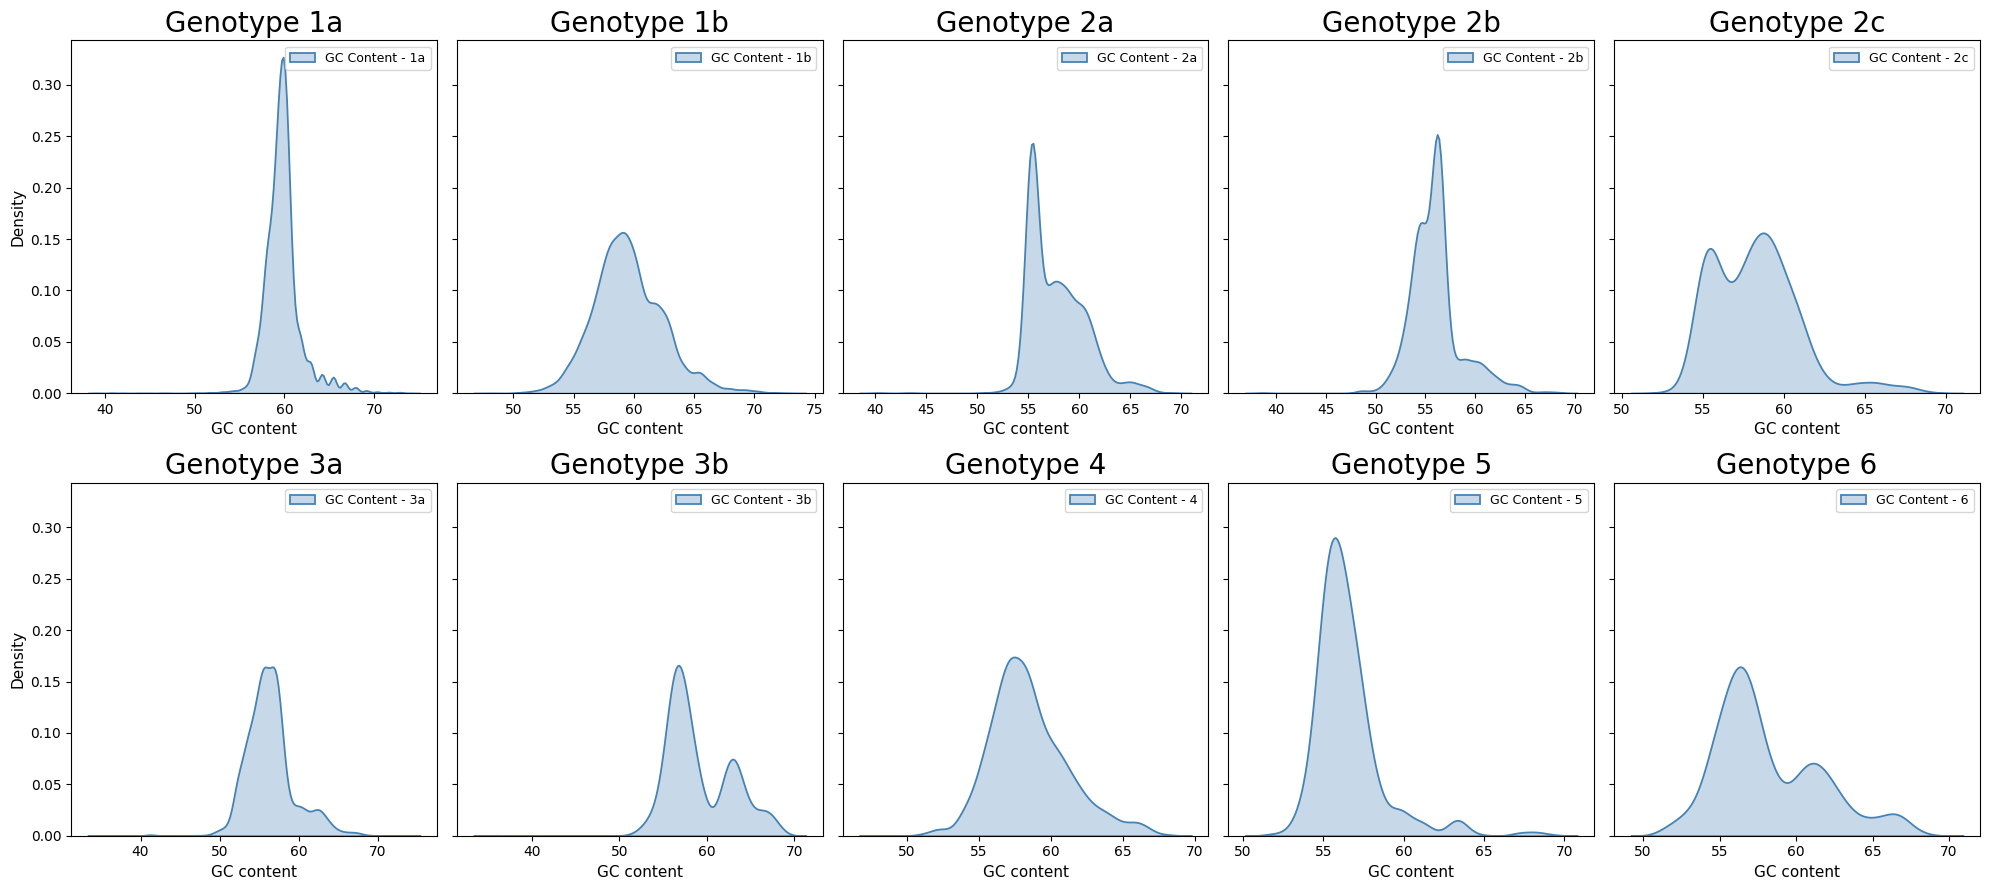

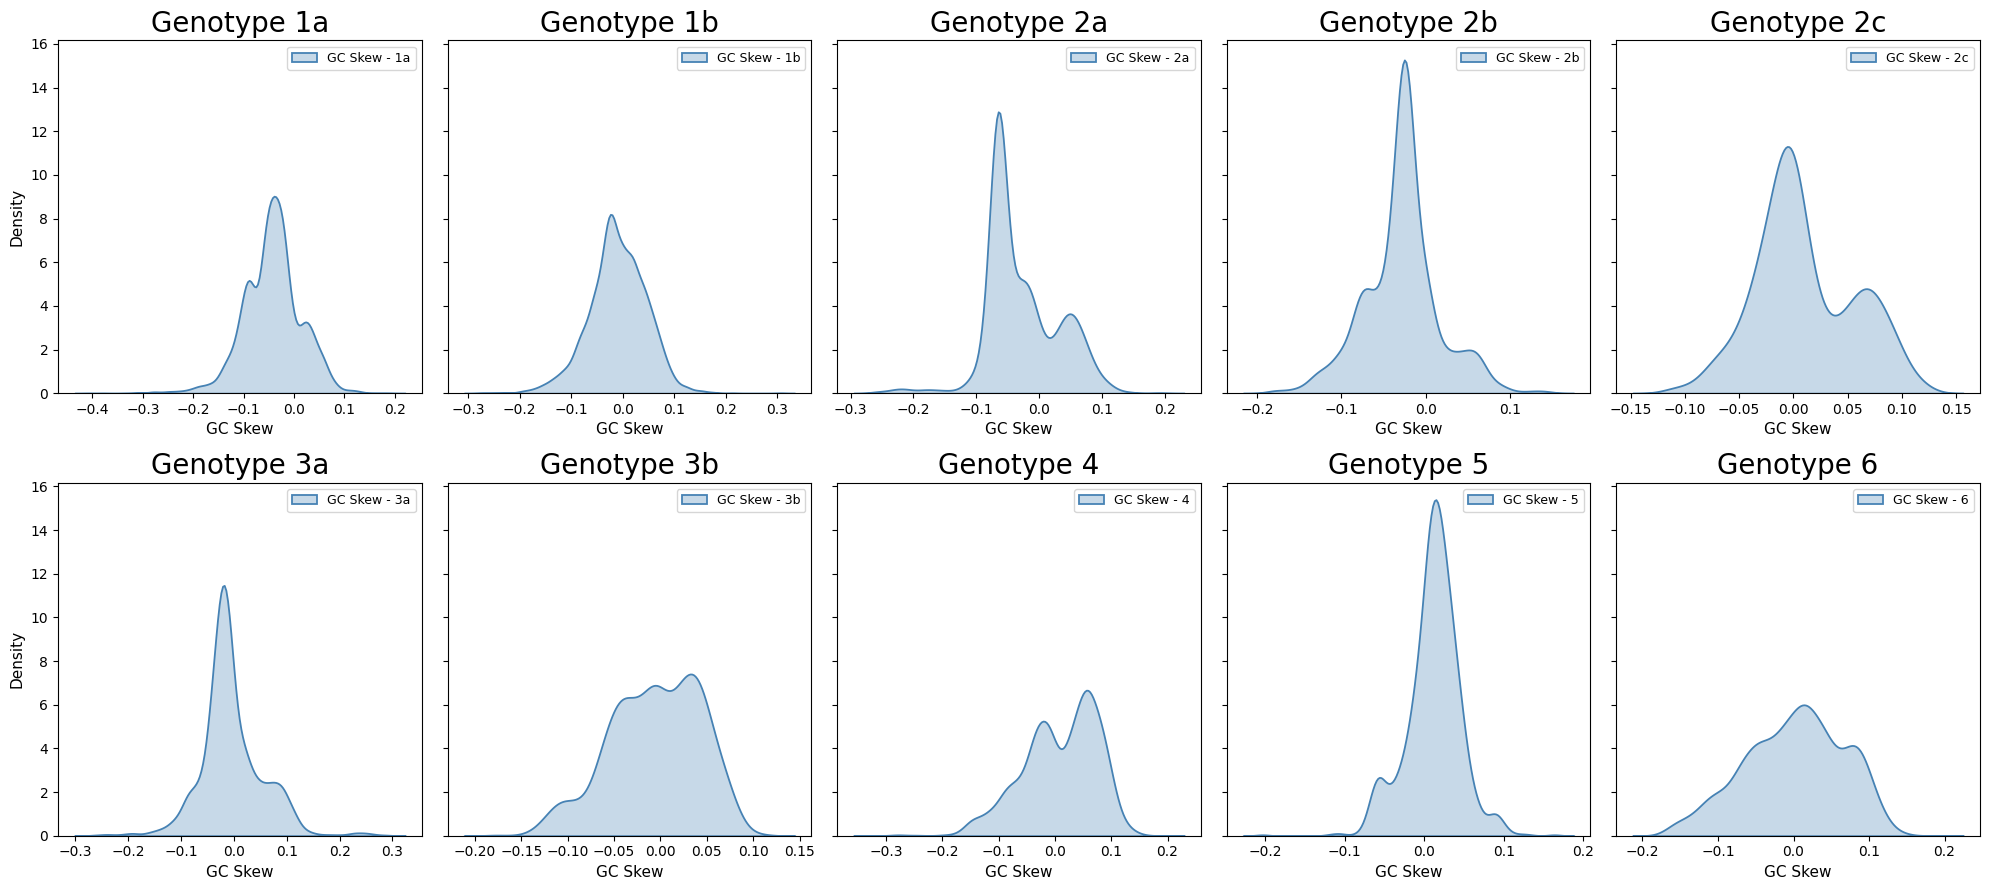

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. SETTINGS
# ============================================================

sequence_col = "seq"
label_col = "genotype"

identity_threshold = 0.90
plots_per_row = 5

df = dataset.copy()
df = df.reset_index(drop=True)


# ============================================================
# 2. SAFETY CHECKS
# ============================================================

if sequence_col not in df.columns:
    raise ValueError(f"Missing sequence column: {sequence_col}")

if label_col not in df.columns:
    raise ValueError(f"Missing genotype column: {label_col}")


print("Original number of sequences:", len(df))


# ============================================================
# 3. SAME SEQUENCE FILTERING
# ============================================================

seq_clean = (
    df[sequence_col]
    .astype(str)
    .str.upper()
    .str.replace("U", "T", regex=False)
)


# Keep only sequences containing A, C, G, T
valid_mask = seq_clean.str.fullmatch(r"[ACGT]+")

df = df[valid_mask].reset_index(drop=True)
seq_clean = seq_clean[valid_mask].reset_index(drop=True)

df[sequence_col] = seq_clean


print(
    "Number of sequences after A/C/G/T filtering:",
    len(df)
)

print("\nSamples per genotype:")
print(df[label_col].value_counts())


# ============================================================
# 4. SAME CD-HIT FILTERING
# ============================================================

cluster_file = f"hcv_cdhit_{int(identity_threshold * 100)}.clstr"


def parse_cdhit_clusters(clstr_file):

    seq_to_cluster = {}
    current_cluster = None

    with open(clstr_file, "r") as f:

        for line in f:

            line = line.strip()

            if line.startswith(">Cluster"):

                current_cluster = int(
                    line.split()[1]
                )

            else:

                match = re.search(
                    r">seq_(\d+)\.\.\.",
                    line
                )

                if match:

                    seq_idx = int(
                        match.group(1)
                    )

                    seq_to_cluster[seq_idx] = current_cluster

    return seq_to_cluster


if os.path.exists(cluster_file):

    seq_to_cluster = parse_cdhit_clusters(
        cluster_file
    )

    df["cluster_id"] = df.index.map(
        seq_to_cluster
    )

    missing_clusters = df["cluster_id"].isna().sum()

    print(
        "\nMissing cluster assignments:",
        missing_clusters
    )

    if missing_clusters > 0:

        df = (
            df
            .dropna(subset=["cluster_id"])
            .reset_index(drop=True)
        )

    df["cluster_id"] = (
        df["cluster_id"]
        .astype(int)
    )

    print(
        "Number of sequences after CD-HIT filtering:",
        len(df)
    )

else:

    print(
        f"\nWarning: {cluster_file} not found."
    )

    print(
        "Using A/C/G/T filtered sequences only."
    )


# ============================================================
# 5. GC CONTENT
# ============================================================

def calculate_gc_content(sequence):
    """
    GC Content (%) =
    ((G + C) / sequence length) * 100
    """

    sequence = str(sequence).upper()

    G = sequence.count("G")
    C = sequence.count("C")

    total = len(sequence)

    if total == 0:
        return np.nan

    return ((G + C) / total) * 100


# ============================================================
# 6. GC SKEW
# ============================================================

def calculate_gc_skew(sequence):
    """
    GC Skew =
    (G - C) / (G + C)

    Standard ratio, not percentage.
    """

    sequence = str(sequence).upper()

    G = sequence.count("G")
    C = sequence.count("C")

    total_gc = G + C

    if total_gc == 0:
        return np.nan

    return (G - C) / total_gc


# ============================================================
# 7. CALCULATE GC FEATURES
# ============================================================

df["GC_Content"] = (
    df[sequence_col]
    .apply(calculate_gc_content)
)

df["GC_Skew"] = (
    df[sequence_col]
    .apply(calculate_gc_skew)
)


# Remove invalid values
df = (
    df
    .dropna(
        subset=[
            "GC_Content",
            "GC_Skew",
            label_col
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 8. FINAL SAMPLE COUNTS
# ============================================================

print("\n====================================")
print("FINAL DATA USED IN THE PLOTS")
print("====================================")

print("\nTotal samples:", len(df))

print("\nSamples per genotype:")
print(df[label_col].value_counts())


# ============================================================
# 9. GENOTYPES
# ============================================================

unique_genotypes = df[label_col].unique()

num_rows = (
    len(unique_genotypes) // plots_per_row
    + (len(unique_genotypes) % plots_per_row > 0)
)


# ============================================================
# 10. GC CONTENT DENSITY PLOT
# ============================================================

fig, axs = plt.subplots(
    num_rows,
    plots_per_row,
    figsize=(20, 4.5 * num_rows),
    squeeze=False,
    sharey=True
)


for i, genotype in enumerate(unique_genotypes):

    row = i // plots_per_row
    col = i % plots_per_row

    ax = axs[row, col]

    genotype_df = df[
        df[label_col] == genotype
    ]


    sns.kdeplot(
        data=genotype_df,
        x="GC_Content",
        fill=True,
        color="steelblue",
        alpha=0.30,
        linewidth=1.3,
        ax=ax
    )


    ax.set_title(
        f"Genotype {genotype}",
        fontsize=20
    )

    ax.set_xlabel(
        "GC content",
        fontsize=11
    )

    ax.set_ylabel(
        "Density",
        fontsize=11
    )


    # Legend like your figure
    ax.legend(
        [f"GC Content - {genotype}"],
        loc="upper right",
        fontsize=9
    )


# Remove empty panels
for i in range(
    len(unique_genotypes),
    num_rows * plots_per_row
):

    fig.delaxes(
        axs.flatten()[i]
    )


plt.tight_layout()
plt.show()


# ============================================================
# 11. GC SKEW DENSITY PLOT
# ============================================================

fig, axs = plt.subplots(
    num_rows,
    plots_per_row,
    figsize=(20, 4.5 * num_rows),
    squeeze=False,
    sharey=True
)


for i, genotype in enumerate(unique_genotypes):

    row = i // plots_per_row
    col = i % plots_per_row

    ax = axs[row, col]

    genotype_df = df[
        df[label_col] == genotype
    ]


    sns.kdeplot(
        data=genotype_df,
        x="GC_Skew",
        fill=True,
        color="steelblue",
        alpha=0.30,
        linewidth=1.3,
        ax=ax
    )


    ax.set_title(
        f"Genotype {genotype}",
        fontsize=20
    )

    ax.set_xlabel(
        "GC Skew",
        fontsize=11
    )

    ax.set_ylabel(
        "Density",
        fontsize=11
    )


    # Legend like your figure
    ax.legend(
        [f"GC Skew - {genotype}"],
        loc="upper right",
        fontsize=9
    )


# Remove empty panels
for i in range(
    len(unique_genotypes),
    num_rows * plots_per_row
):

    fig.delaxes(
        axs.flatten()[i]
    )


plt.tight_layout()
plt.show()

### Integrate Supplementary Features, encoding methods are inculded in different cells

In [ ]:
# integrating features from onehot encoding and gc skew (and/or at/gc content)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np


def calculate_gc_content(sequence):
    """Calculates GC content of a DNA sequence."""
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) > 0 else 0


def calculate_at_gc_skew(sequence):
    """Calculates AT and GC skew of a DNA sequence."""
    a_count, t_count = sequence.count('A'), sequence.count('T')
    g_count, c_count = sequence.count('G'), sequence.count('C')
    at_skew = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
    return at_skew, gc_skew


def nucleotide_composition(sequence):
    """Calculates mono, di, and tri-nucleotide composition."""
    composition = {}
    for n in range(1, 4):  # Mono, di, tri-nucleotide
        counts = {sequence[i:i+n]: sequence[i:i+n].count(sequence[i:i+n])
                  for i in range(len(sequence) - n + 1)}
        total = sum(counts.values())
        composition.update({f"{n}-mer_{key}": val / total for key, val in counts.items()})
    return composition

def one_hot_encode(sequence):
    """
    One-hot encodes a DNA sequence.

    Args:
        sequence (str): DNA sequence consisting of 'A', 'T', 'G', 'C'.

    Returns:
        np.ndarray: One-hot encoded matrix of shape (len(sequence), 4).
    """
    # Define a mapping for each nucleotide
    mapping = {'A': [1, 0, 0, 0],
               'T': [0, 1, 0, 0],
               'G': [0, 0, 1, 0],
               'C': [0, 0, 0, 1]}

    # Convert sequence to one-hot encoded matrix
    one_hot_matrix = np.array([mapping.get(nucleotide, [0, 0, 0, 0]) for nucleotide in sequence])
    return one_hot_matrix.flatten()  # Flatten into a 1D vector


def preprocess_dataframe_with_additional_features(df, ngram_range=(6, 6), max_features=5000):
    """
    Processes the dataframe to encode sequences using CountVectorizer for k-mer frequencies
    and adds additional features like GC content, AT/GC skew, and nucleotide composition.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        ngram_range (tuple): Range of n-grams to use in encoding.
        max_features (int): Maximum number of features to include in CountVectorizer.

    Returns:
        X (DataFrame): Combined feature matrix.
        y (array): Encoded labels.
        vectorizer (CountVectorizer): Fitted vectorizer for future use.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Label encode the genotypes
    le = LabelEncoder()
    df['genotype_encoded'] = le.fit_transform(df['genotype'])

    # one-hot encoding features
    onehot_features = []
    for sequence in df['seq']:
        onehot_features.append(one_hot_encode(sequence))


    # Pad sequences to a fixed length (assuming max_seq_length is the desired length)
    max_seq_length = 1000
    onehot_padded_features = pad_sequences(onehot_features, maxlen=max_seq_length, padding='post').tolist()

    # Calculate additional features
    additional_features = []
    for sequence in df['seq']:
        features = {
            'gc_content': calculate_gc_content(sequence),
        }
        # features = {}
        # Calculate AT/GC skew
        at_skew, gc_skew = calculate_at_gc_skew(sequence)
        # features['at_skew'] = at_skew
        features['gc_skew'] = gc_skew

        # Add mono, di, tri-nucleotide composition
        # features.update(nucleotide_composition(sequence))
        additional_features.append(features)

    additional_features_df = pd.DataFrame(additional_features).fillna(0)

    # Combine k-mer and additional features
    onehot_features_df = pd.DataFrame(onehot_padded_features)
    combined_features = pd.concat([onehot_features_df, additional_features_df], axis=1)

    y = df['genotype_encoded']
    return combined_features, y, le


def train_model_with_additional_features(df):
    """
    Main function to preprocess data using CountVectorizer and additional features,
    train a Random Forest classifier, and evaluate it.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.

    Returns:
        rf (RandomForestClassifier): Trained Random Forest model.
        vectorizer (CountVectorizer): Fitted vectorizer for future use.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Preprocess data
    X, y, le = preprocess_dataframe_with_additional_features(df)


    dataset = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)],axis=1)
    dataset["seq"] = df["seq"].reset_index(drop=True)
    dataset["genotype"] = df["genotype"].reset_index(drop=True)

    # # Split data
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # # Train Random Forest Classifier
    # rf = RandomForestClassifier(n_estimators=100, random_state=42)
    # rf.fit(X_train, y_train)

    # # Evaluate the model
    # y_pred = rf.predict(X_test)
    # print("Classification Report:")
    # print(classification_report(y_test, y_pred, target_names=le.classes_))
    # print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    return le, X, y, dataset


# Example Usage:
data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)
# Assuming 'data' is a DataFrame with columns 'seq' and 'genotype'
label_encoder, X, y, dataset = train_model_with_additional_features(data)

In [ ]:
dataset.drop('gc_skew',axis=1,inplace=True)
# dataset

In [ ]:
# Do the FCGR then combine the extracted features with the gc skew (and/or other additional features)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np


def calculate_gc_content(sequence):
    """Calculates GC content of a DNA sequence."""
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) > 0 else 0


def calculate_at_gc_skew(sequence):
    """Calculates AT and GC skew of a DNA sequence."""
    a_count, t_count = sequence.count('A'), sequence.count('T')
    g_count, c_count = sequence.count('G'), sequence.count('C')
    at_skew = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
    return at_skew, gc_skew


def generate_fcgr(sequence, k=5, grid_size=32):
    """
    Generate a Frequency Chaos Game Representation (FCGR) grid from a DNA sequence.

    Parameters:
        sequence (str): DNA sequence (A, T, C, G).
        k (int): Length of k-mers.
        grid_size (int): Resolution of the FCGR grid (e.g., 32x32 for k=5).

    Returns:
        np.array: FCGR grid of size grid_size x grid_size.
    """
    # Initialize an empty grid
    fcgr = np.zeros((grid_size, grid_size))

    # Scale factor for mapping coordinates
    scale = grid_size / (2 ** k)

    # Create mapping from nucleotide pairs to 2D coordinates
    mapping = {'A': 0, 'T': 1, 'C': 2, 'G': 3}

    # Iterate over k-mers in the sequence
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i + k]

        # Calculate x and y positions based on k-mer
        x, y = 0, 0
        valid_kmer = True
        for j, nucleotide in enumerate(kmer):
            if nucleotide not in mapping:
                valid_kmer = False
                break
            # Update x and y based on nucleotide position
            factor = 2 ** (k - j - 1)
            x += mapping[nucleotide] % 2 * factor
            y += mapping[nucleotide] // 2 * factor

        if valid_kmer:
            # Map x, y to grid and increment the corresponding cell
            grid_x = int(x * scale)
            grid_y = int(y * scale)
            fcgr[grid_y, grid_x] += 1  # Increment the frequency

    return fcgr

def extract_frequencies(fcgr, sub_grid_size=32):
    """
    Divide the FCGR into sub-regions and calculate k-mer frequencies.

    Parameters:
        fcgr (np.array): FCGR grid (e.g., 32x32).
        sub_grid_size (int): Size of sub-grid (e.g., 8x8).

    Returns:
        np.array: Flattened array of frequencies from all sub-regions.
    """
    # Calculate the size of each sub-grid cell
    cell_size = fcgr.shape[0] // sub_grid_size
    frequencies = []

    # Iterate over the sub-grid
    for row in range(sub_grid_size):
        for col in range(sub_grid_size):
            # Extract the sub-region
            sub_region = fcgr[
                row * cell_size:(row + 1) * cell_size,
                col * cell_size:(col + 1) * cell_size
            ]
            # Calculate the frequency as the sum of pixel intensities
            freq = np.sum(sub_region)
            frequencies.append(freq)

    return np.array(frequencies)


def preprocess_dataframe_with_fcgr_encoding(df, k=5,grid_size=32,sub_grid_size=32):
    """
    Processes the dataframe to encode sequences using FCGR and adds additional features.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        resolution (int): Resolution for FCGR encoding.

    Returns:
        X (DataFrame): Combined feature matrix.
        y (array): Encoded labels.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Label encode the genotypes
    le = LabelEncoder()
    df['genotype_encoded'] = le.fit_transform(df['genotype'])

    # Calculate FCGR features
    fcgr_features = []
    for _, row in df.iterrows():
        sequence = row['seq']
        # label = row['genotype']

        # Generate FCGR for the sequence
        fcgr = generate_fcgr(sequence, k, grid_size)

        # Extract frequencies from the FCGR
        frequencies = extract_frequencies(fcgr, sub_grid_size)
        fcgr_features.append(frequencies)

    # Calculate additional features
    additional_features = []
    for sequence in df['seq']:
        features = {}
        features = {
            'gc_content': calculate_gc_content(sequence),
        }
        # Calculate AT/GC skew
        at_skew, gc_skew = calculate_at_gc_skew(sequence)
        # features['at_skew'] = at_skew
        features['gc_skew'] = gc_skew

        additional_features.append(features)

    additional_features_df = pd.DataFrame(additional_features).fillna(0)

    # Combine FCGR and additional features
    # fcgr_features_df = pd.DataFrame(fcgr_features, columns=[f"fcgr_{i}" for i in range(fcgr_features.shape[1])])
    fcgr_features_df = pd.DataFrame(fcgr_features)
    combined_features = pd.concat([fcgr_features_df, additional_features_df], axis=1)

    y = df['genotype_encoded']
    return combined_features, y, le


def train_model_with_additional_features(df, resolution=5):
    """
    Main function to preprocess data using FCGR encoding and additional features,
    train a Random Forest classifier, and evaluate it.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        resolution (int): Resolution for FCGR encoding.

    Returns:
        rf (RandomForestClassifier): Trained Random Forest model.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Preprocess data
    X, y, le = preprocess_dataframe_with_fcgr_encoding(df,k=5)

    # # Split data
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # # Train Random Forest Classifier
    # rf = RandomForestClassifier(n_estimators=100, random_state=42)
    # rf.fit(X_train, y_train)

    # # Evaluate the model
    # y_pred = rf.predict(X_test)
    # print("Classification Report:")
    # print(classification_report(y_test, y_pred, target_names=le.classes_))
    # print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


    dataset = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)],axis=1)
    dataset["seq"] = df["seq"].reset_index(drop=True)
    dataset["genotype"] = df["genotype"].reset_index(drop=True)

    return le, X, y, dataset


# Example Usage:
data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)
# Assuming 'data' is a DataFrame with columns 'seq' and 'genotype'
label_encoder, X, y, dataset = train_model_with_additional_features(data)

In [ ]:
dataset.drop('gc_skew',axis=1,inplace=True)

In [ ]:
# integrating features from kmer encoding and gc skew (and/or at/gc content)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np


def calculate_gc_content(sequence):
    """Calculates GC content of a DNA sequence."""
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) > 0 else 0


def calculate_at_gc_skew(sequence):
    """Calculates AT and GC skew of a DNA sequence."""
    a_count, t_count = sequence.count('A'), sequence.count('T')
    g_count, c_count = sequence.count('G'), sequence.count('C')
    at_skew = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
    return at_skew, gc_skew


def nucleotide_composition(sequence):
    """Calculates mono, di, and tri-nucleotide composition."""
    composition = {}
    for n in range(1, 4):  # Mono, di, tri-nucleotide
        counts = {sequence[i:i+n]: sequence[i:i+n].count(sequence[i:i+n])
                  for i in range(len(sequence) - n + 1)}
        total = sum(counts.values())
        composition.update({f"{n}-mer_{key}": val / total for key, val in counts.items()})
    return composition


def preprocess_dataframe_with_additional_features(df, ngram_range=(5, 5), max_features=1000):
    """
    Processes the dataframe to encode sequences using CountVectorizer for k-mer frequencies
    and adds additional features like GC content, AT/GC skew, and nucleotide composition.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        ngram_range (tuple): Range of n-grams to use in encoding.
        max_features (int): Maximum number of features to include in CountVectorizer.

    Returns:
        X (DataFrame): Combined feature matrix.
        y (array): Encoded labels.
        vectorizer (CountVectorizer): Fitted vectorizer for future use.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Label encode the genotypes
    le = LabelEncoder()
    df['genotype_encoded'] = le.fit_transform(df['genotype'])

    # Use CountVectorizer for k-mer encoding
    vectorizer = CountVectorizer(analyzer='char', ngram_range=ngram_range, max_features=max_features)
    kmer_features = vectorizer.fit_transform(df['seq']).toarray()
    kmer_feature_names = vectorizer.get_feature_names_out()

    # Calculate additional features
    additional_features = []
    for sequence in df['seq']:
        features = {
            'gc_content': calculate_gc_content(sequence),
        }
        # features = {}
        # Calculate AT/GC skew
        at_skew, gc_skew = calculate_at_gc_skew(sequence)
        # features['at_skew'] = at_skew
        features['gc_skew'] = gc_skew

        # Add mono, di, tri-nucleotide composition
        # features.update(nucleotide_composition(sequence))
        additional_features.append(features)

    additional_features_df = pd.DataFrame(additional_features).fillna(0)

    # Combine k-mer and additional features
    kmer_features_df = pd.DataFrame(kmer_features, columns=kmer_feature_names)
    combined_features = pd.concat([kmer_features_df, additional_features_df], axis=1)

    y = df['genotype_encoded']
    return combined_features, y, vectorizer, le


def train_model_with_additional_features(df):
    """
    Main function to preprocess data using CountVectorizer and additional features,
    train a Random Forest classifier, and evaluate it.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.

    Returns:
        rf (RandomForestClassifier): Trained Random Forest model.
        vectorizer (CountVectorizer): Fitted vectorizer for future use.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Preprocess data
    X, y, vectorizer, le = preprocess_dataframe_with_additional_features(df)

    # Split data
    # # Split data
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # # Train Random Forest Classifier
    # rf = RandomForestClassifier(n_estimators=100, random_state=42)
    # rf.fit(X_train, y_train)

    # # Evaluate the model
    # y_pred = rf.predict(X_test)
    # print("Classification Report:")
    # print(classification_report(y_test, y_pred, target_names=le.classes_))
    # print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


    dataset = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)],axis=1)
    dataset["seq"] = df["seq"].reset_index(drop=True)
    dataset["genotype"] = df["genotype"].reset_index(drop=True)

    return le, X, y, dataset


# Example Usage:
data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)
# Assuming 'data' is a DataFrame with columns 'seq' and 'genotype'
label_encoder, X, y, dataset = train_model_with_additional_features(data)

In [ ]:
dataset.drop('gc_content',axis=1,inplace=True)

In [ ]:
# integrating features from label encoding and gc skew (and/or at/gc content)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np


def calculate_gc_content(sequence):
    """Calculates GC content of a DNA sequence."""
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) > 0 else 0


def calculate_at_gc_skew(sequence):
    """Calculates AT and GC skew of a DNA sequence."""
    a_count, t_count = sequence.count('A'), sequence.count('T')
    g_count, c_count = sequence.count('G'), sequence.count('C')
    at_skew = (a_count - t_count) / (a_count + t_count) if (a_count + t_count) > 0 else 0
    gc_skew = (g_count - c_count) / (g_count + c_count) if (g_count + c_count) > 0 else 0
    return at_skew, gc_skew


def nucleotide_composition(sequence):
    """Calculates mono, di, and tri-nucleotide composition."""
    composition = {}
    for n in range(1, 4):  # Mono, di, tri-nucleotide
        counts = {sequence[i:i+n]: sequence[i:i+n].count(sequence[i:i+n])
                  for i in range(len(sequence) - n + 1)}
        total = sum(counts.values())
        composition.update({f"{n}-mer_{key}": val / total for key, val in counts.items()})
    return composition

def label_encode_dna_sequence(sequence):
    """Label encodes a DNA sequence using integer mapping.

    Args:
        sequence (str): DNA sequence consisting of 'A', 'T', 'G', 'C'.

    Returns:
        list: Label encoded sequence as list of integers.
    """
    encoded_sequence = []
    mapping = {'A': 1, 'T': 4, 'C': 2, 'G': 3}
    for base in sequence:
        encoded_sequence.append(mapping.get(base, 0))  # Default to 0 for unknown bases
    return encoded_sequence


def preprocess_dataframe_with_additional_features(df, ngram_range=(5, 5), max_features=1000):
    """
    Processes the dataframe to encode sequences using label encoding
    and adds additional features like GC content, AT/GC skew, and nucleotide composition.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.
        ngram_range (tuple): Range of n-grams to use in encoding.
        max_features (int): Maximum number of features to include in CountVectorizer.

    Returns:
        X (DataFrame): Combined feature matrix.
        y (array): Encoded labels.
        label_encoder (LabelEncoder): Fitted label encoder for future use.
    """
    # Label encode the genotypes
    le = LabelEncoder()
    df['genotype_encoded'] = le.fit_transform(df['genotype'])

    # Label encode the DNA sequences
    df['encoded_seq'] = df['seq'].apply(label_encode_dna_sequence)

    # Pad sequences to a fixed length
    max_seq_length = 1000
    padded_sequences = pad_sequences(df['encoded_seq'], maxlen=max_seq_length, padding='post')
    label_encoded_features = pd.DataFrame(padded_sequences)

    # Calculate additional features
    additional_features = []
    for sequence in df['seq']:
        features = {
            'gc_content': calculate_gc_content(sequence),
        }
        # features = {}
        # Calculate AT/GC skew
        at_skew, gc_skew = calculate_at_gc_skew(sequence)
        # features['at_skew'] = at_skew
        features['gc_skew'] = gc_skew

        # Add mono, di, tri-nucleotide composition
        # features.update(nucleotide_composition(sequence))
        additional_features.append(features)

    additional_features_df = pd.DataFrame(additional_features).fillna(0)

    # Combine label encoded sequences and additional features
    combined_features = pd.concat([label_encoded_features, additional_features_df], axis=1)

    y = df['genotype_encoded']
    return combined_features, y, le


def train_model_with_additional_features(df):
    """
    Main function to preprocess data using label encoding and additional features,
    train a Random Forest classifier, and evaluate it.

    Args:
        df (pd.DataFrame): DataFrame with 'seq' and 'genotype' columns.

    Returns:
        le (LabelEncoder): Fitted label encoder for future use.
        X (DataFrame): Feature matrix.
        y (array): Encoded labels.
    """
    # Preprocess data
    X, y, le = preprocess_dataframe_with_additional_features(df)

    dataset = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)],axis=1)
    dataset["seq"] = df["seq"].reset_index(drop=True)
    dataset["genotype"] = df["genotype"].reset_index(drop=True)

    return le, X, y, dataset


# Example Usage:
data = pd.read_csv('data.csv')
data.drop_duplicates(subset='seq',keep='first', inplace=True)
# Assuming 'data' is a DataFrame with columns 'seq' and 'genotype'
label_encoder, X, y, dataset = train_model_with_additional_features(data)

In [ ]:
dataset.drop('gc_skew',axis=1,inplace=True)

### Random undersampling VS SMOTE

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)
from sklearn.preprocessing import label_binarize

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb


# ============================================================
# 1. Train-test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.2,
    stratify=y,
    random_state=42
)

class_labels = np.unique(y_train)


# ============================================================
# 2. Choose classifier
# ============================================================

# XGBoost
# clf = xgb.XGBClassifier(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1,
#     eval_metric="mlogloss"
# )

# Random Forest
# clf = RandomForestClassifier(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1
# )

# KNN
clf = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)


# ============================================================
# 3. Pipeline with random undersampling
# ============================================================
pipeline = Pipeline([
    ("undersampling", RandomUnderSampler(
        sampling_strategy="auto",
        random_state=42
    )),
    ("clf", clf)
])


# ============================================================
# 4. Cross-validation accuracy on training set only
# ============================================================
# cv = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

# cv_scores = cross_val_score(
#     pipeline,
#     X_train,
#     y_train,
#     cv=cv,
#     scoring="accuracy"
# )

# print("Cross-validation accuracy scores:", cv_scores)
# print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
# print(f"CV std: {cv_scores.std():.4f}")


# ============================================================
# 5. Train final model
# ============================================================
pipeline.fit(X_train, y_train)


# ============================================================
# 6. Predictions
# ============================================================
y_pred = pipeline.predict(X_test)

if hasattr(pipeline.named_steps["clf"], "predict_proba"):
    y_proba = pipeline.predict_proba(X_test)
else:
    y_proba = None


# ============================================================
# 7. Accuracy and MCC
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"\nHold-out test accuracy: {accuracy:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")


# ============================================================
# 8. Confusion matrix
# ============================================================
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_labels],
    columns=[f"Pred_{c}" for c in class_labels]
)

print("\nConfusion Matrix:")
print(cm_df)


# ============================================================
# 9. Per-class precision, recall, F1-score
# ============================================================
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_labels,
    zero_division=0
)


# ============================================================
# 10. Per-class specificity
# ============================================================
specificity = []

for i, cls in enumerate(class_labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity.append(spec)


# ============================================================
# 11. Per-class metrics table
# ============================================================
per_class_metrics = pd.DataFrame({
    "Class": class_labels,
    "Precision": precision,
    "Recall/Sensitivity": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "Support": support
})

print("\nPer-class metrics:")
print(per_class_metrics)


# ============================================================
# 12. Macro, weighted, and overall/micro metrics
# ============================================================

# Macro averages
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

# Weighted averages
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# Overall/micro averages
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

# Macro and weighted specificity
macro_specificity = np.mean(specificity)

weighted_specificity = np.average(
    specificity,
    weights=support
)

# Overall/micro specificity from one-vs-rest aggregation
TP_total = np.trace(cm)

FP_total = (cm.sum(axis=0) - np.diag(cm)).sum()
FN_total = (cm.sum(axis=1) - np.diag(cm)).sum()

TN_total = cm.sum() * len(class_labels) - TP_total - FP_total - FN_total

overall_specificity = (
    TN_total / (TN_total + FP_total)
    if (TN_total + FP_total) > 0
    else 0
)


# ============================================================
# 13. Multi-class AUC-ROC
# ============================================================
auc_roc_macro = np.nan
auc_roc_weighted = np.nan

if y_proba is not None:
    y_test_binarized = label_binarize(
        y_test,
        classes=class_labels
    )

    auc_roc_macro = roc_auc_score(
        y_test_binarized,
        y_proba,
        average="macro",
        multi_class="ovr"
    )

    auc_roc_weighted = roc_auc_score(
        y_test_binarized,
        y_proba,
        average="weighted",
        multi_class="ovr"
    )

    print(f"\nMacro AUC-ROC (OvR): {auc_roc_macro:.4f}")
    print(f"Weighted AUC-ROC (OvR): {auc_roc_weighted:.4f}")
else:
    print("\nAUC-ROC was not computed because the classifier does not provide predict_proba().")


# ============================================================
# 14. Summary metrics table
# ============================================================
summary_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",

        "Overall Precision",
        "Overall Recall/Sensitivity",
        "Overall Specificity",
        "Overall F1-score",

        "Macro Precision",
        "Macro Recall/Sensitivity",
        "Macro Specificity",
        "Macro F1-score",

        "Weighted Precision",
        "Weighted Recall/Sensitivity",
        "Weighted Specificity",
        "Weighted F1-score",

        "Macro AUC-ROC",
        "Weighted AUC-ROC",

        "Matthews Correlation Coefficient"
    ],
    "Value": [
        accuracy,

        overall_precision,
        overall_recall,
        overall_specificity,
        overall_f1,

        macro_precision,
        macro_recall,
        macro_specificity,
        macro_f1,

        weighted_precision,
        weighted_recall,
        weighted_specificity,
        weighted_f1,

        auc_roc_macro,
        auc_roc_weighted,

        mcc
    ]
})

print("\nSummary metrics:")
print(summary_metrics)


# ============================================================
# 15. Optional classification report
# ============================================================
print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=class_labels,
        zero_division=0
    )
)

In [ ]:
### here we implement the MLP

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

from imblearn.under_sampling import RandomUnderSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


# ============================================================
# 1. Encode labels
# ============================================================
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y.values)

class_labels = np.unique(y_encoded)
class_names = label_encoder.inverse_transform(class_labels)
num_classes = len(class_labels)


# ============================================================
# 2. Train-test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)


# ============================================================
# 3. Random undersampling on training set only
# ============================================================
rus = RandomUnderSampler(
    sampling_strategy="auto",
    random_state=42
)

X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)


# ============================================================
# 4. Train-validation split from balanced training data
# ============================================================
X_train_mlp, X_val, y_train_mlp, y_val = train_test_split(
    X_train_balanced,
    y_train_balanced,
    test_size=0.2,
    stratify=y_train_balanced,
    random_state=42
)


# ============================================================
# 5. Convert labels to categorical
# ============================================================
y_train_cat = to_categorical(y_train_mlp, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)


# ============================================================
# 6. Define MLP model
# ============================================================
model = Sequential()
model.add(Dense(256, activation="relu", input_shape=(X_train_mlp.shape[1],)))
model.add(Dense(num_classes, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 7. Train model
# ============================================================
history = model.fit(
    X_train_mlp,
    y_train_cat,
    batch_size=32,
    epochs=10,
    verbose=1,
    validation_data=(X_val, y_val_cat)
)


# ============================================================
# 8. Predict on untouched test set
# ============================================================
y_proba = model.predict(X_test)

y_pred = np.argmax(y_proba, axis=1)


# ============================================================
# 9. Accuracy and MCC
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"\nHold-out test accuracy: {accuracy:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")


# ============================================================
# 10. Confusion matrix
# ============================================================
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

print("\nConfusion Matrix:")
print(cm_df)


# ============================================================
# 11. Per-class precision, recall, F1
# ============================================================
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_labels,
    zero_division=0
)


# ============================================================
# 12. Per-class specificity
# ============================================================
specificity = []

for i, cls in enumerate(class_labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity.append(spec)


per_class_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall/Sensitivity": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "Support": support
})

print("\nPer-class metrics:")
print(per_class_metrics)


# ============================================================
# 13. Overall, macro, and weighted metrics
# ============================================================
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_specificity = np.mean(specificity)
weighted_specificity = np.average(specificity, weights=support)

TP_total = np.trace(cm)
FP_total = (cm.sum(axis=0) - np.diag(cm)).sum()
FN_total = (cm.sum(axis=1) - np.diag(cm)).sum()
TN_total = cm.sum() * len(class_labels) - TP_total - FP_total - FN_total

overall_specificity = (
    TN_total / (TN_total + FP_total)
    if (TN_total + FP_total) > 0
    else 0
)


# ============================================================
# 14. Multi-class AUC-ROC
# ============================================================
y_test_binarized = label_binarize(
    y_test,
    classes=class_labels
)

auc_roc_macro = roc_auc_score(
    y_test_binarized,
    y_proba,
    average="macro",
    multi_class="ovr"
)

auc_roc_weighted = roc_auc_score(
    y_test_binarized,
    y_proba,
    average="weighted",
    multi_class="ovr"
)


# ============================================================
# 15. Summary metrics
# ============================================================
summary_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",

        "Overall Precision",
        "Overall Recall/Sensitivity",
        "Overall Specificity",
        "Overall F1-score",

        "Macro Precision",
        "Macro Recall/Sensitivity",
        "Macro Specificity",
        "Macro F1-score",

        "Weighted Precision",
        "Weighted Recall/Sensitivity",
        "Weighted Specificity",
        "Weighted F1-score",

        "Macro AUC-ROC",
        "Weighted AUC-ROC",

        "Matthews Correlation Coefficient"
    ],
    "Value": [
        accuracy,

        overall_precision,
        overall_recall,
        overall_specificity,
        overall_f1,

        macro_precision,
        macro_recall,
        macro_specificity,
        macro_f1,

        weighted_precision,
        weighted_recall,
        weighted_specificity,
        weighted_f1,

        auc_roc_macro,
        auc_roc_weighted,

        mcc
    ]
})

print("\nSummary metrics:")
print(summary_metrics)

In [ ]:
################## SMOTE full metrics
################## you need to have the input X & y ready (apply encoding method first and then run this code)

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb


# ============================================================
# 1. Prepare X and y
# ============================================================

# If X and y are already defined, keep these lines:
X_data = X.values
y_data = y.values

# Encode class labels to integers
# This is especially important for XGBoost
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_data)

class_labels = np.unique(y_encoded)
class_names = label_encoder.inverse_transform(class_labels)
num_classes = len(class_labels)


# ============================================================
# 2. Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)


# ============================================================
# 3. Define classifier
# ============================================================

# XGBoost
# clf = xgb.XGBClassifier(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1,
#     eval_metric="mlogloss"
# )

# Random Forest
clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# KNN
# clf = KNeighborsClassifier(
#     n_neighbors=5
# )

# Distance-weighted KNN
# clf = KNeighborsClassifier(
#     n_neighbors=5,
#     weights="distance"
# )


# ============================================================
# 4. Define SMOTE pipeline
# ============================================================

pipeline = Pipeline([
    ("smote", SMOTE(
        sampling_strategy="auto",
        random_state=42
    )),
    ("clf", clf)
])


# ============================================================
# 5. Optional cross-validation on training set only
# ============================================================

# cv = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

# cv_scores = cross_val_score(
#     pipeline,
#     X_train,
#     y_train,
#     cv=cv,
#     scoring="accuracy"
# )

# print("Cross-validation accuracy scores:", cv_scores)
# print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
# print(f"CV std: {cv_scores.std():.4f}")


# ============================================================
# 6. Train final model on training set only
# ============================================================

pipeline.fit(X_train, y_train)


# ============================================================
# 7. Predict on untouched hold-out test set
# ============================================================

y_pred = pipeline.predict(X_test)

if hasattr(pipeline.named_steps["clf"], "predict_proba"):
    y_proba = pipeline.predict_proba(X_test)
else:
    y_proba = None


# ============================================================
# 8. Accuracy and MCC
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"\nHold-out test accuracy: {accuracy:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")


# ============================================================
# 9. Confusion matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

print("\nConfusion Matrix:")
print(cm_df)


# ============================================================
# 10. Per-class precision, recall, F1-score
# ============================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_labels,
    zero_division=0
)


# ============================================================
# 11. Per-class specificity
# ============================================================

specificity = []

for i, cls in enumerate(class_labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity.append(spec)


# ============================================================
# 12. Per-class metrics table
# ============================================================

per_class_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall/Sensitivity": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "Support": support
})

print("\nPer-class metrics:")
print(per_class_metrics)


# ============================================================
# 13. Overall, macro, and weighted averages
# ============================================================

# Overall / micro averages
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

# Macro averages
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

# Weighted averages
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# Macro and weighted specificity
macro_specificity = np.mean(specificity)

weighted_specificity = np.average(
    specificity,
    weights=support
)

# Overall specificity using one-vs-rest aggregation
TP_total = np.trace(cm)
FP_total = (cm.sum(axis=0) - np.diag(cm)).sum()
FN_total = (cm.sum(axis=1) - np.diag(cm)).sum()

TN_total = cm.sum() * len(class_labels) - TP_total - FP_total - FN_total

overall_specificity = (
    TN_total / (TN_total + FP_total)
    if (TN_total + FP_total) > 0
    else 0
)


# ============================================================
# 14. Multi-class AUC-ROC
# ============================================================

auc_roc_macro = np.nan
auc_roc_weighted = np.nan

if y_proba is not None:
    y_test_binarized = label_binarize(
        y_test,
        classes=class_labels
    )

    auc_roc_macro = roc_auc_score(
        y_test_binarized,
        y_proba,
        average="macro",
        multi_class="ovr"
    )

    auc_roc_weighted = roc_auc_score(
        y_test_binarized,
        y_proba,
        average="weighted",
        multi_class="ovr"
    )

    print(f"\nMacro AUC-ROC (OvR): {auc_roc_macro:.4f}")
    print(f"Weighted AUC-ROC (OvR): {auc_roc_weighted:.4f}")

else:
    print("\nAUC-ROC was not computed because the classifier does not provide predict_proba().")


# ============================================================
# 15. Summary metrics table
# ============================================================

summary_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",

        "Overall Precision",
        "Overall Recall/Sensitivity",
        "Overall Specificity",
        "Overall F1-score",

        "Macro Precision",
        "Macro Recall/Sensitivity",
        "Macro Specificity",
        "Macro F1-score",

        "Weighted Precision",
        "Weighted Recall/Sensitivity",
        "Weighted Specificity",
        "Weighted F1-score",

        "Macro AUC-ROC",
        "Weighted AUC-ROC",

        "Matthews Correlation Coefficient"
    ],
    "Value": [
        accuracy,

        overall_precision,
        overall_recall,
        overall_specificity,
        overall_f1,

        macro_precision,
        macro_recall,
        macro_specificity,
        macro_f1,

        weighted_precision,
        weighted_recall,
        weighted_specificity,
        weighted_f1,

        auc_roc_macro,
        auc_roc_weighted,

        mcc
    ]
})

print("\nSummary metrics:")
print(summary_metrics)


# ============================================================
# 16. Classification report
# ============================================================

# print("\nClassification report:")
# print(
#     classification_report(
#         y_test,
#         y_pred,
#         target_names=class_names,
#         zero_division=0
#     )
# )


# # ============================================================
# # 17. Optional: save outputs as CSV files
# # ============================================================

# per_class_metrics.to_csv("smote_per_class_metrics.csv", index=False)
# summary_metrics.to_csv("smote_summary_metrics.csv", index=False)
# cm_df.to_csv("smote_confusion_matrix.csv")

# print("\nSaved files:")
# print("smote_per_class_metrics.csv")
# print("smote_summary_metrics.csv")
# print("smote_confusion_matrix.csv")


Hold-out test accuracy: 0.9904
Matthews Correlation Coefficient (MCC): 0.9888

Confusion Matrix:
        Pred_0  Pred_1  Pred_2  Pred_3  Pred_4  Pred_5  Pred_6  Pred_7  \
True_0    1720       2       0       0       0       0       0       1   
True_1       9    1614       1       2       0       1       0       1   
True_2       0       1     409       1       1       0       0       1   
True_3       0       3       1     378       0       1       0       0   
True_4       0       2       0       0     177       0       0       0   
True_5       2       3       0       0       0    1634       5       0   
True_6       0       0       0       0       0       3     283       1   
True_7       6       7       1       0       0       3       0    1089   
True_8       0       0       0       0       0       0       0       1   
True_9       1       5       0       0       0       1       0       6   

        Pred_8  Pred_9  
True_0       0       4  
True_1       0       1  
True_2      

In [ ]:
### A version for the MLP

################## SMOTE full metrics for MLP
################## You need to have the input X & y ready
################## Apply encoding method first, then run this code

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


# ============================================================
# 0. Reproducibility
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 1. Prepare X and y
# ============================================================

# If X and y are already defined, keep these lines:
X_data = X.values
y_data = y.values

# Encode class labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_data)

class_labels = np.unique(y_encoded)
class_names = label_encoder.inverse_transform(class_labels)
num_classes = len(class_labels)


# ============================================================
# 2. Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)


# ============================================================
# 3. Apply SMOTE only on the training data
# ============================================================

smote = SMOTE(
    sampling_strategy="auto",
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Class distribution before SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())


# ============================================================
# 4. Split SMOTE-balanced training data into train/validation
# ============================================================

X_train_mlp, X_val, y_train_mlp, y_val = train_test_split(
    X_train_smote,
    y_train_smote,
    test_size=0.2,
    stratify=y_train_smote,
    random_state=42
)


# ============================================================
# 5. Convert labels to categorical format
# ============================================================

y_train_cat = to_categorical(
    y_train_mlp,
    num_classes=num_classes
)

y_val_cat = to_categorical(
    y_val,
    num_classes=num_classes
)

y_test_cat = to_categorical(
    y_test,
    num_classes=num_classes
)


# ============================================================
# 6. Define MLP model
# ============================================================

model = Sequential()

model.add(
    Dense(
        256,
        activation="relu",
        input_shape=(X_train_mlp.shape[1],)
    )
)

model.add(
    Dense(
        num_classes,
        activation="softmax"
    )
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ============================================================
# 7. Train MLP model
# ============================================================

history = model.fit(
    X_train_mlp,
    y_train_cat,
    batch_size=32,
    epochs=10,
    verbose=1,
    validation_data=(X_val, y_val_cat)
)


# ============================================================
# 8. Predict on untouched hold-out test set
# ============================================================

y_proba = model.predict(X_test)

y_pred = np.argmax(
    y_proba,
    axis=1
)


# ============================================================
# 9. Accuracy and MCC
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

mcc = matthews_corrcoef(
    y_test,
    y_pred
)

print(f"\nHold-out test accuracy: {accuracy:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")


# ============================================================
# 10. Confusion matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

print("\nConfusion Matrix:")
print(cm_df)


# ============================================================
# 11. Per-class precision, recall, F1-score
# ============================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_labels,
    zero_division=0
)


# ============================================================
# 12. Per-class specificity
# ============================================================

specificity = []

for i, cls in enumerate(class_labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity.append(spec)


# ============================================================
# 13. Per-class metrics table
# ============================================================

per_class_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall/Sensitivity": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "Support": support
})

print("\nPer-class metrics:")
print(per_class_metrics)


# ============================================================
# 14. Overall, macro, and weighted averages
# ============================================================

# Overall / micro averages
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

# Macro averages
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

# Weighted averages
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# Macro specificity
macro_specificity = np.mean(specificity)

# Weighted specificity
weighted_specificity = np.average(
    specificity,
    weights=support
)

# Overall specificity using one-vs-rest aggregation
TP_total = np.trace(cm)

FP_total = (
    cm.sum(axis=0) - np.diag(cm)
).sum()

FN_total = (
    cm.sum(axis=1) - np.diag(cm)
).sum()

TN_total = (
    cm.sum() * len(class_labels)
    - TP_total
    - FP_total
    - FN_total
)

overall_specificity = (
    TN_total / (TN_total + FP_total)
    if (TN_total + FP_total) > 0
    else 0
)


# ============================================================
# 15. Multi-class AUC-ROC
# ============================================================

auc_roc_macro = np.nan
auc_roc_weighted = np.nan

y_test_binarized = label_binarize(
    y_test,
    classes=class_labels
)

auc_roc_macro = roc_auc_score(
    y_test_binarized,
    y_proba,
    average="macro",
    multi_class="ovr"
)

auc_roc_weighted = roc_auc_score(
    y_test_binarized,
    y_proba,
    average="weighted",
    multi_class="ovr"
)

print(f"\nMacro AUC-ROC (OvR): {auc_roc_macro:.4f}")
print(f"Weighted AUC-ROC (OvR): {auc_roc_weighted:.4f}")


# ============================================================
# 16. Summary metrics table
# ============================================================

summary_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",

        "Overall Precision",
        "Overall Recall/Sensitivity",
        "Overall Specificity",
        "Overall F1-score",

        "Macro Precision",
        "Macro Recall/Sensitivity",
        "Macro Specificity",
        "Macro F1-score",

        "Weighted Precision",
        "Weighted Recall/Sensitivity",
        "Weighted Specificity",
        "Weighted F1-score",

        "Macro AUC-ROC",
        "Weighted AUC-ROC",

        "Matthews Correlation Coefficient"
    ],
    "Value": [
        accuracy,

        overall_precision,
        overall_recall,
        overall_specificity,
        overall_f1,

        macro_precision,
        macro_recall,
        macro_specificity,
        macro_f1,

        weighted_precision,
        weighted_recall,
        weighted_specificity,
        weighted_f1,

        auc_roc_macro,
        auc_roc_weighted,

        mcc
    ]
})

print("\nSummary metrics:")
print(summary_metrics)


# ============================================================
# 17. Classification report
# ============================================================

# print("\nClassification report:")
# print(
#     classification_report(
#         y_test,
#         y_pred,
#         target_names=class_names,
#         zero_division=0
#     )
# )


# ============================================================
# 18. Optional: save outputs as CSV files
# ============================================================

# per_class_metrics.to_csv("smote_mlp_per_class_metrics.csv", index=False)
# summary_metrics.to_csv("smote_mlp_summary_metrics.csv", index=False)
# cm_df.to_csv("smote_mlp_confusion_matrix.csv")

# print("\nSaved files:")
# print("smote_mlp_per_class_metrics.csv")
# print("smote_mlp_summary_metrics.csv")
# print("smote_mlp_confusion_matrix.csv")

### RF and XGB Feature Importance

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:36:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Feature  Importance
0   ttaag    0.023601
1   gggtg    0.015933
2   acata    0.015882
3   gtcct    0.013905
4   taagg    0.013331
5   agtga    0.013163
6   gtcta    0.012022
7   gacat    0.010753
8   tatac    0.010735
9   tatgt    0.010566


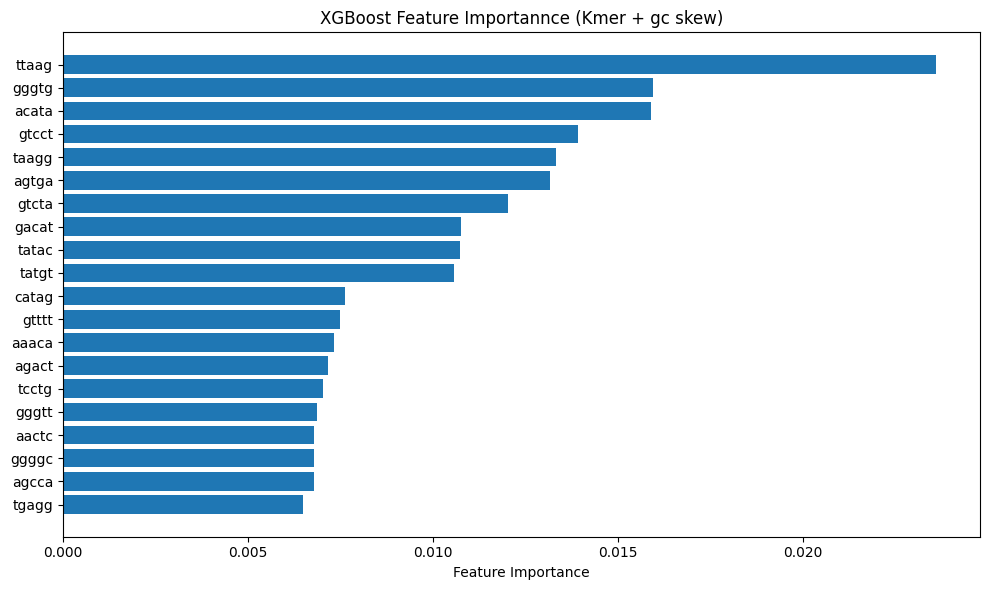

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split

# Prepare your data
# X = df.drop('target', axis=1)
# y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Train XGBoost model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)

# Get feature importances
importances = xgb.feature_importances_
feature_names = X.columns

# Create a DataFrame for ranking
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Show top 10 features
print(importance_df.head(10))

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:20][::-1], importance_df['Importance'][:20][::-1])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importannce (Kmer + gc skew)')
plt.tight_layout()
plt.show()

  Feature  Importance
0   tatac    0.006210
1   atagc    0.005844
2   ctgcg    0.005569
3   gtcct    0.005304
4   agact    0.004813
5   gacat    0.004812
6   aactc    0.004343
7   tgatc    0.004289
8   gggga    0.004285
9   gggtg    0.003982


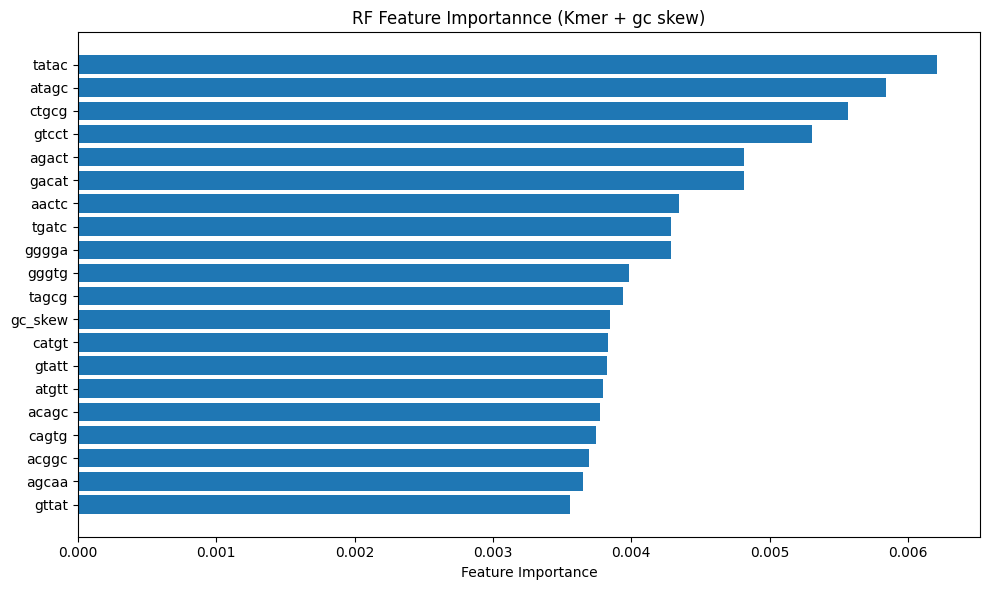

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split

# Prepare your data
# X = df.drop('target', axis=1)
# y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Train RF model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for ranking
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Show top 10 features
print(importance_df.head(10))

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:20][::-1], importance_df['Importance'][:20][::-1])
plt.xlabel('Feature Importance')
plt.title('RF Feature Importannce (Kmer + gc skew)')
plt.tight_layout()
plt.show()

### CD-HIT-EST clustering
 Solve Sequence-identity leakage

In [ ]:
!apt-get install cd-hit

In [ ]:
import pandas as pd
dataset = pd.read_csv('data.csv')
dataset.drop_duplicates(subset='seq', inplace=True)
dataset.reset_index(drop=True, inplace=True)

dataset.shape

(43362, 3)

In [ ]:
import re
import subprocess
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder


# ============================================================
# 1. Input dataframe
# ============================================================

# dataset should contain:
# - raw sequence column: "seq"
# - label column: "genotype"
# - encoded feature columns

df = dataset.copy()
df = df.reset_index(drop=True)

sequence_col = "seq"
label_col = "genotype"

identity_threshold = 0.90


# ============================================================
# 2. Safety checks
# ============================================================

if sequence_col not in df.columns:
    raise ValueError(f"Missing sequence column: {sequence_col}")

if label_col not in df.columns:
    raise ValueError(f"Missing label column: {label_col}")


# ============================================================
# 3. Clean sequences only for CD-HIT
#    The original dataframe features are not modified
# ============================================================

seq_clean = (
    df[sequence_col]
    .astype(str)
    .str.upper()
    .str.replace("U", "T", regex=False)
)

valid_mask = seq_clean.str.fullmatch(r"[ACGT]+")

df = df[valid_mask].reset_index(drop=True)
seq_clean = seq_clean[valid_mask].reset_index(drop=True)

print("Number of valid sequences:", len(df))
print("\nClass distribution:")
print(df[label_col].value_counts())


# ============================================================
# 4. Write sequences to FASTA for CD-HIT
# ============================================================

fasta_path = f"hcv_sequences_cleaned_{int(identity_threshold * 100)}.fasta"

with open(fasta_path, "w") as f:
    for idx, seq in enumerate(seq_clean):
        f.write(f">seq_{idx}\n")
        f.write(f"{seq}\n")

print(f"\nFASTA file saved to: {fasta_path}")


# ============================================================
# 5. Run CD-HIT-EST at 90% identity
# ============================================================

cdhit_output = f"hcv_cdhit_{int(identity_threshold * 100)}"

# Recommended word size for CD-HIT-EST
if identity_threshold >= 0.95:
    word_size = "10"
elif identity_threshold >= 0.90:
    word_size = "8"
else:
    word_size = "7"

cmd = [
    "cd-hit-est",
    "-i", fasta_path,
    "-o", cdhit_output,
    "-c", str(identity_threshold),
    "-n", word_size,
    "-M", "0",
    "-T", "0"
]

print("\nRunning CD-HIT-EST...")
print(" ".join(cmd))

subprocess.run(cmd, check=True)

print("\nCD-HIT-EST finished.")
print(f"Cluster file: {cdhit_output}.clstr")


# ============================================================
# 6. Parse CD-HIT cluster file
# ============================================================

def parse_cdhit_clusters(clstr_file):
    """
    Parses CD-HIT .clstr file.

    Returns:
        Dictionary mapping sequence index to cluster ID.
    """

    seq_to_cluster = {}
    current_cluster = None

    with open(clstr_file, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith(">Cluster"):
                current_cluster = int(line.split()[1])

            else:
                match = re.search(r">seq_(\d+)\.\.\.", line)

                if match:
                    seq_idx = int(match.group(1))
                    seq_to_cluster[seq_idx] = current_cluster

    return seq_to_cluster


cluster_file = f"{cdhit_output}.clstr"

seq_to_cluster = parse_cdhit_clusters(cluster_file)

df["cluster_id"] = df.index.map(seq_to_cluster)

missing_clusters = df["cluster_id"].isna().sum()
print("\nMissing cluster assignments:", missing_clusters)

if missing_clusters > 0:
    df = df.dropna(subset=["cluster_id"]).reset_index(drop=True)

df["cluster_id"] = df["cluster_id"].astype(int)

print("Number of CD-HIT clusters:", df["cluster_id"].nunique())


# ============================================================
# 7. Prepare X, y, and groups
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    df[label_col].values
)

class_labels = np.unique(y_encoded)

class_names = label_encoder.inverse_transform(
    class_labels
)

groups = df["cluster_id"].values


# ============================================================
# 8. Select encoded feature columns
#    Sequence column is excluded from X
# ============================================================

non_feature_cols = [
    label_col,
    "genotype",
    "genotype_encoded",
    "label",
    "target",
    "class",
    "cluster_id",
    sequence_col,
    "seq",
    "sequence",
    "accession",
    "id"
]

feature_cols = [
    col for col in df.columns
    if col not in non_feature_cols
]

X = df[feature_cols]

# Keep only numeric encoded features
X = X.select_dtypes(include=[np.number])

### check
print("Feature columns used:")
print(list(X.columns))

for suspicious_col in ["genotype", "genotype_encoded", "label", "target", "class", "cluster_id"]:
    if suspicious_col in X.columns:
        raise ValueError(f"Leakage detected: {suspicious_col} is included in X.")


if X.shape[1] == 0:
    raise ValueError(
        "No numeric encoded feature columns found. "
        "Please make sure dataset contains encoded numeric columns."
    )

print("\nNumber of encoded feature columns:", X.shape[1])


# ============================================================
# 9. Cluster-aware train-test split
# ============================================================

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X=X,
        y=y_encoded,
        groups=groups
    )
)


# ============================================================
# 10. Final outputs
# ============================================================

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)

y_train = y_encoded[train_idx]
y_test = y_encoded[test_idx]


# ============================================================
# 11. Safety check: no cluster overlap
# ============================================================

train_clusters = set(df.iloc[train_idx]["cluster_id"].values)
test_clusters = set(df.iloc[test_idx]["cluster_id"].values)

overlap = train_clusters.intersection(test_clusters)

print("\nCluster-aware split summary:")
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])
print("Training clusters:", len(train_clusters))
print("Test clusters:", len(test_clusters))
print("Overlapping clusters:", len(overlap))

if len(overlap) == 0:
    print("Correct: no CD-HIT cluster appears in both training and test sets.")
else:
    print("Warning: cluster overlap detected.")

print("\nTraining class distribution:")
print(pd.Series(label_encoder.inverse_transform(y_train)).value_counts())

print("\nTest class distribution:")
print(pd.Series(label_encoder.inverse_transform(y_test)).value_counts())

print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nClasses:")
for encoded_label, class_name in zip(class_labels, class_names):
    print(encoded_label, "=", class_name)

In [ ]:
# Sequence length
df["sequence_length"] = df["seq"].astype(str).str.len()

# Length-based complete/partial classification
COMPLETE_THRESHOLD = 9000

df["sequence_type"] = df["sequence_length"].apply(
    lambda x: "Complete" if x >= COMPLETE_THRESHOLD else "Partial"
)

summary = (
    df.groupby(["genotype", "sequence_type"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
)

# Make sure both columns exist
for col in ["Complete", "Partial"]:
    if col not in summary.columns:
        summary[col] = 0

summary = summary[
    ["genotype", "Complete", "Partial"]
]

summary.columns = [
    "HCV Genotype",
    "Number of Complete Sequences",
    "Number of Partial Sequences"
]

print(summary)

print("\nTotal complete:",
      (df["sequence_type"] == "Complete").sum())

print("Total partial:",
      (df["sequence_type"] == "Partial").sum())

print("Total sequences:",
      len(df))

  HCV Genotype  Number of Complete Sequences  Number of Partial Sequences
0           1a                            11                         8449
1           1b                           112                         7541
2           2a                            21                         1573
3           2b                           113                         1559
4           2c                             8                          761
5           3a                            23                         6998
6           3b                             2                         1236
7            4                            58                         3707
8            5                             2                         1162
9            6                            53                         3075

Total complete: 403
Total partial: 36061
Total sequences: 36464


In [ ]:
X_train = X_train.values
X_test = X_test.values

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score
)

import xgboost as xgb
import numpy as np
import pandas as pd


# ============================================================
# 1. Full metrics function
# ============================================================

def calculate_full_metrics(
    y_test,
    y_pred,
    y_proba,
    class_labels,
    class_names
):
    accuracy = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=class_labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"True_{c}" for c in class_names],
        columns=[f"Pred_{c}" for c in class_names]
    )

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=class_labels,
        zero_division=0
    )

    specificity = []

    for i, cls in enumerate(class_labels):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificity.append(spec)

    auc_per_class = []

    if y_proba is not None:
        y_test_binarized = label_binarize(
            y_test,
            classes=class_labels
        )

        for i in range(len(class_labels)):
            try:
                auc_value = roc_auc_score(
                    y_test_binarized[:, i],
                    y_proba[:, i]
                )
            except ValueError:
                auc_value = np.nan

            auc_per_class.append(auc_value)
    else:
        auc_per_class = [np.nan] * len(class_labels)

    per_class_metrics = pd.DataFrame({
        "Class": class_names,
        "Precision": precision,
        "Recall/Sensitivity": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "AUC-ROC": auc_per_class,
        "Support": support
    })

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    macro_specificity = np.mean(specificity)

    weighted_specificity = np.average(
        specificity,
        weights=support
    )

    if y_proba is not None:
        y_test_binarized = label_binarize(
            y_test,
            classes=class_labels
        )

        try:
            macro_auc_roc = roc_auc_score(
                y_test_binarized,
                y_proba,
                average="macro",
                multi_class="ovr"
            )

            weighted_auc_roc = roc_auc_score(
                y_test_binarized,
                y_proba,
                average="weighted",
                multi_class="ovr"
            )
        except ValueError:
            macro_auc_roc = np.nan
            weighted_auc_roc = np.nan
    else:
        macro_auc_roc = np.nan
        weighted_auc_roc = np.nan

    summary_metrics = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall/Sensitivity",
            "Macro Specificity",
            "Macro F1-score",
            "Macro AUC-ROC",
            "Weighted Precision",
            "Weighted Recall/Sensitivity",
            "Weighted Specificity",
            "Weighted F1-score",
            "Weighted AUC-ROC",
            "Matthews Correlation Coefficient"
        ],
        "Value": [
            accuracy,
            macro_precision,
            macro_recall,
            macro_specificity,
            macro_f1,
            macro_auc_roc,
            weighted_precision,
            weighted_recall,
            weighted_specificity,
            weighted_f1,
            weighted_auc_roc,
            mcc
        ]
    })

    return summary_metrics, per_class_metrics, cm_df


# ============================================================
# 2. Define all models
# ============================================================

models = {
    "xgboost": xgb.XGBClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "knn": KNeighborsClassifier(
        n_neighbors=5
    ),

    "mlp": MLPClassifier(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=128,
        learning_rate="adaptive",
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    )
}


# ============================================================
# 3. Run all models
# ============================================================

all_summary_results = []

for model_name, clf in models.items():

    print("\n" + "=" * 70)
    print(f"Training model: {model_name}")
    print("=" * 70)

    # Models that need scaling
    if model_name in ["knn", "mlp"]:
        steps = [
            ("scaler", StandardScaler()),

            # Uncomment this if you want SMOTE
            ("smote", SMOTE(
                sampling_strategy="auto",
                random_state=42
            )),

            ("clf", clf)
        ]
    else:
        steps = [
            # Uncomment this if you want SMOTE
            ("smote", SMOTE(
                sampling_strategy="auto",
                random_state=42
            )),

            ("clf", clf)
        ]

    pipeline = Pipeline(steps)

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["clf"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)
    else:
        y_proba = None

    # Metrics
    summary_metrics, per_class_metrics, cm_df = calculate_full_metrics(
        y_test=y_test,
        y_pred=y_pred,
        y_proba=y_proba,
        class_labels=class_labels,
        class_names=class_names
    )

    # Add model name
    summary_metrics.insert(0, "Model", model_name)
    per_class_metrics.insert(0, "Model", model_name)

    # Save individual results
    summary_file = f"cdhit90_{model_name}_summary_metrics.csv"
    per_class_file = f"cdhit90_{model_name}_per_class_metrics.csv"
    cm_file = f"cdhit90_{model_name}_confusion_matrix.csv"

    summary_metrics.to_csv(summary_file, index=False)
    per_class_metrics.to_csv(per_class_file, index=False)
    cm_df.to_csv(cm_file)

    print("\nSummary metrics:")
    print(summary_metrics)

    print("\nPer-class metrics:")
    print(per_class_metrics)

    print("\nConfusion matrix:")
    print(cm_df)

    print("\nSaved files:")
    print(summary_file)
    print(per_class_file)
    print(cm_file)

    all_summary_results.append(summary_metrics)


# ============================================================
# 4. Combine all summary metrics into one table
# ============================================================

all_summary_results_df = pd.concat(
    all_summary_results,
    axis=0,
    ignore_index=True
)

all_summary_results_df.to_csv(
    "cdhit90_all_models_summary_metrics.csv",
    index=False
)

print("\n" + "=" * 70)
print("All models completed.")
print("=" * 70)

print("\nCombined summary metrics:")
print(all_summary_results_df)

print("\nSaved combined summary file:")
print("cdhit90_all_models_summary_metrics.csv")


Training model: xgboost

Summary metrics:
      Model                            Metric     Value
0   xgboost                          Accuracy  0.916156
1   xgboost                   Macro Precision  0.888773
2   xgboost          Macro Recall/Sensitivity  0.886623
3   xgboost                 Macro Specificity  0.988800
4   xgboost                    Macro F1-score  0.884628
5   xgboost                     Macro AUC-ROC  0.987428
6   xgboost                Weighted Precision  0.920485
7   xgboost       Weighted Recall/Sensitivity  0.916156
8   xgboost              Weighted Specificity  0.971848
9   xgboost                 Weighted F1-score  0.916555
10  xgboost                  Weighted AUC-ROC  0.986404
11  xgboost  Matthews Correlation Coefficient  0.882898

Per-class metrics:
     Model Class  Precision  Recall/Sensitivity  Specificity  F1-score  \
0  xgboost    1a   0.955238            0.899023     0.960123  0.926278   
1  xgboost    1b   0.797189            0.981054     0.963299 

In [ ]:
########################################################### Random Undersampling #############################################################################
from imblearn.under_sampling import RandomUnderSampler

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score
)

import xgboost as xgb
import numpy as np
import pandas as pd


# ============================================================
# 1. Full metrics function
# ============================================================

def calculate_full_metrics(
    y_test,
    y_pred,
    y_proba,
    class_labels,
    class_names
):
    accuracy = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=class_labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"True_{c}" for c in class_names],
        columns=[f"Pred_{c}" for c in class_names]
    )

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=class_labels,
        zero_division=0
    )

    specificity = []

    for i, cls in enumerate(class_labels):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificity.append(spec)

    auc_per_class = []

    if y_proba is not None:
        y_test_binarized = label_binarize(
            y_test,
            classes=class_labels
        )

        for i in range(len(class_labels)):
            try:
                auc_value = roc_auc_score(
                    y_test_binarized[:, i],
                    y_proba[:, i]
                )
            except ValueError:
                auc_value = np.nan

            auc_per_class.append(auc_value)
    else:
        auc_per_class = [np.nan] * len(class_labels)

    per_class_metrics = pd.DataFrame({
        "Class": class_names,
        "Precision": precision,
        "Recall/Sensitivity": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "AUC-ROC": auc_per_class,
        "Support": support
    })

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    macro_specificity = np.mean(specificity)

    weighted_specificity = np.average(
        specificity,
        weights=support
    )

    if y_proba is not None:
        y_test_binarized = label_binarize(
            y_test,
            classes=class_labels
        )

        try:
            macro_auc_roc = roc_auc_score(
                y_test_binarized,
                y_proba,
                average="macro",
                multi_class="ovr"
            )

            weighted_auc_roc = roc_auc_score(
                y_test_binarized,
                y_proba,
                average="weighted",
                multi_class="ovr"
            )
        except ValueError:
            macro_auc_roc = np.nan
            weighted_auc_roc = np.nan
    else:
        macro_auc_roc = np.nan
        weighted_auc_roc = np.nan

    summary_metrics = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall/Sensitivity",
            "Macro Specificity",
            "Macro F1-score",
            "Macro AUC-ROC",
            "Weighted Precision",
            "Weighted Recall/Sensitivity",
            "Weighted Specificity",
            "Weighted F1-score",
            "Weighted AUC-ROC",
            "Matthews Correlation Coefficient"
        ],
        "Value": [
            accuracy,
            macro_precision,
            macro_recall,
            macro_specificity,
            macro_f1,
            macro_auc_roc,
            weighted_precision,
            weighted_recall,
            weighted_specificity,
            weighted_f1,
            weighted_auc_roc,
            mcc
        ]
    })

    return summary_metrics, per_class_metrics, cm_df


# ============================================================
# 2. Define all models
# ============================================================

models = {
    "xgboost": xgb.XGBClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "knn": KNeighborsClassifier(
        n_neighbors=5
    ),

    "mlp": MLPClassifier(
        hidden_layer_sizes=(256,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=128,
        learning_rate="adaptive",
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    )
}


# ============================================================
# 3. Run all models with Random Undersampling
# ============================================================

all_summary_results = []

for model_name, clf in models.items():

    print("\n" + "=" * 70)
    print(f"Training model: {model_name}")
    print("=" * 70)

    # Models that need scaling
    if model_name in ["knn", "mlp"]:
        steps = [
            ("scaler", StandardScaler()),

            ("undersampling", RandomUnderSampler(
                sampling_strategy="auto",
                random_state=42
            )),

            ("clf", clf)
        ]
    else:
        steps = [
            ("undersampling", RandomUnderSampler(
                sampling_strategy="auto",
                random_state=42
            )),

            ("clf", clf)
        ]

    pipeline = Pipeline(steps)

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["clf"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)
    else:
        y_proba = None

    # Metrics
    summary_metrics, per_class_metrics, cm_df = calculate_full_metrics(
        y_test=y_test,
        y_pred=y_pred,
        y_proba=y_proba,
        class_labels=class_labels,
        class_names=class_names
    )

    # Add model name
    summary_metrics.insert(0, "Model", model_name)
    per_class_metrics.insert(0, "Model", model_name)

    # Save individual results
    summary_file = f"cdhit90_undersampling_{model_name}_summary_metrics.csv"
    per_class_file = f"cdhit90_undersampling_{model_name}_per_class_metrics.csv"
    cm_file = f"cdhit90_undersampling_{model_name}_confusion_matrix.csv"

    summary_metrics.to_csv(summary_file, index=False)
    per_class_metrics.to_csv(per_class_file, index=False)
    cm_df.to_csv(cm_file)

    print("\nSummary metrics:")
    print(summary_metrics)

    print("\nPer-class metrics:")
    print(per_class_metrics)

    print("\nConfusion matrix:")
    print(cm_df)

    print("\nSaved files:")
    print(summary_file)
    print(per_class_file)
    print(cm_file)

    all_summary_results.append(summary_metrics)


# ============================================================
# 4. Combine all summary metrics into one table
# ============================================================

all_summary_results_df = pd.concat(
    all_summary_results,
    axis=0,
    ignore_index=True
)

all_summary_results_df.to_csv(
    "cdhit90_undersampling_all_models_summary_metrics.csv",
    index=False
)

print("\n" + "=" * 70)
print("All models completed.")
print("=" * 70)

print("\nCombined summary metrics:")
print(all_summary_results_df)

print("\nSaved combined summary file:")
print("cdhit90_undersampling_all_models_summary_metrics.csv")


Training model: xgboost

Summary metrics:
      Model                            Metric     Value
0   xgboost                          Accuracy  0.861774
1   xgboost                   Macro Precision  0.720636
2   xgboost          Macro Recall/Sensitivity  0.830047
3   xgboost                 Macro Specificity  0.982126
4   xgboost                    Macro F1-score  0.757733
5   xgboost                     Macro AUC-ROC  0.969215
6   xgboost                Weighted Precision  0.873362
7   xgboost       Weighted Recall/Sensitivity  0.861774
8   xgboost              Weighted Specificity  0.959489
9   xgboost                 Weighted F1-score  0.864069
10  xgboost                  Weighted AUC-ROC  0.957673
11  xgboost  Matthews Correlation Coefficient  0.810701

Per-class metrics:
     Model Class  Precision  Recall/Sensitivity  Specificity  F1-score  \
0  xgboost    1a   0.932990            0.825407     0.943885  0.875907   
1  xgboost    1b   0.821301            0.946458     0.969719 


Top features: k-mer + XGBoost + SMOTE
   Feature  Importance  Rank
0    cgatt  402.573059     1
1    ttggc  348.980499     2
2    aacgg  291.679779     3
3    tgtga  246.335495     4
4    cagag  229.522934     5
5    ctttc  219.958374     6
6    ttcaa  219.227737     7
7    gactt  203.984146     8
8    ttact  190.474487     9
9    aatgt  186.270447    10
10   ctagt  178.018814    11
11   tagat  167.469559    12
12   aagtc  156.709091    13
13   gttat  156.444824    14
14   cccac  150.757492    15
15   cttcg  150.396332    16
16   agtcc  140.364197    17
17   gttgg  137.054810    18
18   gcaaa  128.394928    19
19   gaact  126.402939    20


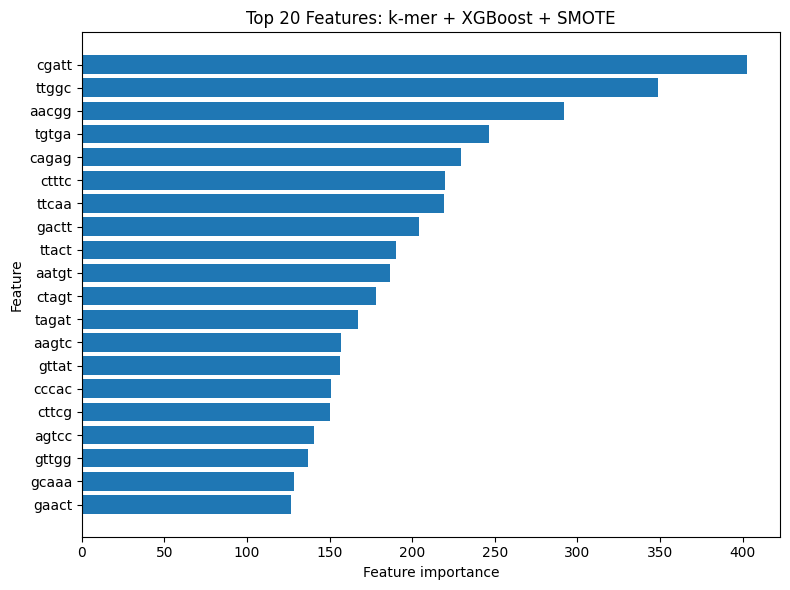

Saved figure: top20_features_kmer_xgboost_smote.png

Top features: k-mer + GC content + GC skew + Random Forest + SMOTE
       Feature  Importance  Rank
0   gc_content    0.008262     1
1        atcct    0.005349     2
2        gtcat    0.005307     3
3        gccta    0.005048     4
4        tcatc    0.004297     5
5        ctgcg    0.004123     6
6        catcc    0.004110     7
7        ggagg    0.004101     8
8        agact    0.004076     9
9        gggga    0.003796    10
10     gc_skew    0.003735    11
11       ggcaa    0.003622    12
12       ttcct    0.003583    13
13       cgtgg    0.003559    14
14       aatgt    0.003491    15
15       cgatt    0.003088    16
16       ggctg    0.003073    17
17       atcat    0.003067    18
18       tctgc    0.003030    19
19       aagtc    0.002973    20


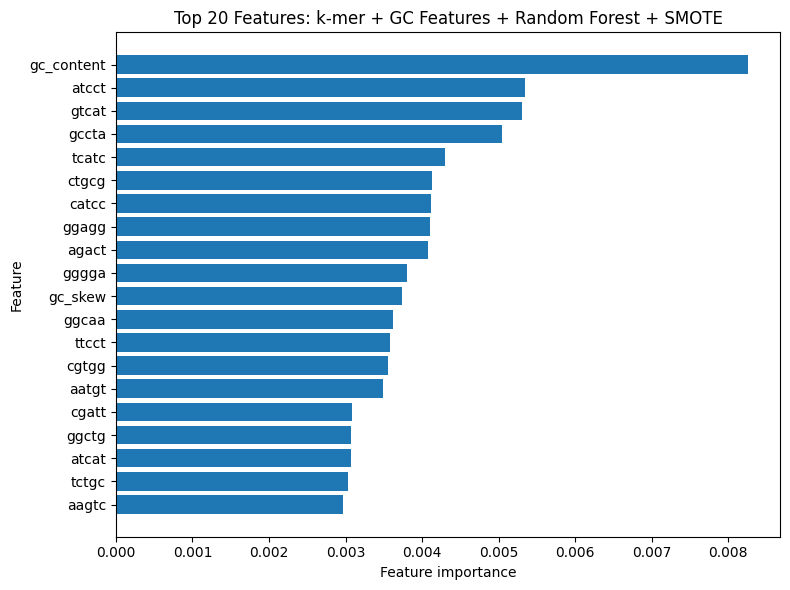

Saved figure: top20_features_kmer_gc_random_forest_smote.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb


# ============================================================
# 1. Safety check: X_train must be a DataFrame
# ============================================================

def check_dataframe(X, name="X"):
    if not isinstance(X, pd.DataFrame):
        raise TypeError(
            f"{name} must be a pandas DataFrame to preserve feature names. "
            "Do not use X_train = X_train.values before feature importance extraction."
        )


# ============================================================
# 2. XGBoost feature importance using gain
# ============================================================

def get_xgb_top_features_gain(
    fitted_pipeline,
    feature_names,
    top_k=20
):
    model = fitted_pipeline.named_steps["clf"]
    booster = model.get_booster()

    importance_dict = booster.get_score(
        importance_type="gain"
    )

    rows = []

    for i, feature_name in enumerate(feature_names):

        # XGBoost may use either "f0" style names or original feature names
        f_key = f"f{i}"

        if feature_name in importance_dict:
            importance = importance_dict[feature_name]
        elif f_key in importance_dict:
            importance = importance_dict[f_key]
        else:
            importance = 0.0

        rows.append({
            "Feature": feature_name,
            "Importance": importance
        })

    importance_df = pd.DataFrame(rows)

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    importance_df["Rank"] = np.arange(1, len(importance_df) + 1)

    return importance_df.head(top_k)


# ============================================================
# 3. Random Forest feature importance
# ============================================================

def get_rf_top_features(
    fitted_pipeline,
    feature_names,
    top_k=20
):
    model = fitted_pipeline.named_steps["clf"]

    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    importance_df["Rank"] = np.arange(1, len(importance_df) + 1)

    return importance_df.head(top_k)


# ============================================================
# 4. Plot top-k features
# ============================================================

def plot_top_features(
    top_features_df,
    title,
    output_path
):
    plot_df = top_features_df.sort_values(
        by="Importance",
        ascending=True
    )

    plt.figure(figsize=(8, 6))

    plt.barh(
        plot_df["Feature"],
        plot_df["Importance"]
    )

    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved figure: {output_path}")


# ============================================================
# 5. Selected Model 1:
#    k-mer + XGBoost + SMOTE
# ============================================================

# X_train_kmer and X_test_kmer should contain only k-mer features
# Example:
X_train_kmer = X_train.copy()
X_test_kmer  = X_test.copy()

check_dataframe(X_train_kmer, "X_train_kmer")

xgb_kmer_smote_pipeline = Pipeline([
    ("smote", SMOTE(
        sampling_strategy="auto",
        random_state=42
    )),
    ("clf", xgb.XGBClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ))
])

xgb_kmer_smote_pipeline.fit(
    X_train_kmer,
    y_train
)

top_k_xgb = get_xgb_top_features_gain(
    fitted_pipeline=xgb_kmer_smote_pipeline,
    feature_names=X_train_kmer.columns,
    top_k=20
)

print("\nTop features: k-mer + XGBoost + SMOTE")
print(top_k_xgb)

top_k_xgb.to_csv(
    "top20_features_kmer_xgboost_smote.csv",
    index=False
)

plot_top_features(
    top_features_df=top_k_xgb,
    title="Top 20 Features: k-mer + XGBoost + SMOTE",
    output_path="top20_features_kmer_xgboost_smote.png"
)


# ============================================================
# 6. Selected Model 2:
#    k-mer + GC content + GC skew + Random Forest + SMOTE
# ============================================================

# X_train_kmer_gc and X_test_kmer_gc should contain:
# - k-mer features
# - GC content
# - GC skew
#
# Example:
X_train_kmer_gc = X_train.copy()
X_test_kmer_gc  = X_test.copy()

check_dataframe(X_train_kmer_gc, "X_train_kmer_gc")

rf_kmer_gc_smote_pipeline = Pipeline([
    ("smote", SMOTE(
        sampling_strategy="auto",
        random_state=42
    )),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_kmer_gc_smote_pipeline.fit(
    X_train_kmer_gc,
    y_train
)

top_k_rf = get_rf_top_features(
    fitted_pipeline=rf_kmer_gc_smote_pipeline,
    feature_names=X_train_kmer_gc.columns,
    top_k=20
)

print("\nTop features: k-mer + GC content + GC skew + Random Forest + SMOTE")
print(top_k_rf)

top_k_rf.to_csv(
    "top20_features_kmer_gc_random_forest_smote.csv",
    index=False
)

plot_top_features(
    top_features_df=top_k_rf,
    title="Top 20 Features: k-mer + GC Features + Random Forest + SMOTE",
    output_path="top20_features_kmer_gc_random_forest_smote.png"
)

In [ ]:
#### statistical analysis

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier


# ============================================================
# INPUTS YOU MUST PROVIDE
# ============================================================

# You must already have:
# X_train: your feature dataframe or array
# y_train: your class labels

# ------------------------------------------------------------
# CASE 1:
# If X_train already contains both k-mer features and GC features,
# define your GC feature names here.
# ------------------------------------------------------------

gc_feature_names = ["gc_content", "gc_skew"]  # modify if needed

# Convert X_train to DataFrame if it is not already
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train)

# Detect which GC columns exist
available_gc_features = [col for col in gc_feature_names if col in X_train.columns]

print("Available GC features:", available_gc_features)

# k-mer only features = remove GC-related columns
X_kmer = X_train.drop(columns=available_gc_features, errors="ignore")

# k-mer + GC features = keep all features
X_kmer_gc = X_train.copy()


# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_train)

print("Classes:", list(label_encoder.classes_))


# ============================================================
# MODELS
# ============================================================

n_classes = len(np.unique(y_encoded))

models = {
    "RF": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight=None
    ),

    "XGB": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob" if n_classes > 2 else "binary:logistic",
        num_class=n_classes if n_classes > 2 else None,
        eval_metric="mlogloss" if n_classes > 2 else "logloss",
        random_state=42,
        n_jobs=-1
    )
}


# Remove num_class=None for binary XGBoost
if n_classes == 2:
    models["XGB"].set_params(num_class=None)


# ============================================================
# CROSS-VALIDATION CONFIG
# ============================================================

n_splits = 5

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)


# ============================================================
# EXPERIMENTAL CONDITIONS
# ============================================================

conditions = [
    {
        "condition_name": "kmer_no_smote",
        "X": X_kmer,
        "smote": "No",
        "gc_features": "No"
    },
    {
        "condition_name": "kmer_smote",
        "X": X_kmer,
        "smote": "Yes",
        "gc_features": "No"
    },
    {
        "condition_name": "kmer_gc_no_smote",
        "X": X_kmer_gc,
        "smote": "No",
        "gc_features": "Yes"
    },
    {
        "condition_name": "kmer_gc_smote",
        "X": X_kmer_gc,
        "smote": "Yes",
        "gc_features": "Yes"
    }
]


# ============================================================
# MAIN LOOP TO GENERATE results.csv
# ============================================================

all_results = []

for model_name, base_model in models.items():

    print("\n" + "=" * 70)
    print("Running model:", model_name)
    print("=" * 70)

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_kmer, y_encoded), start=1):

        print(f"\nFold {fold_idx}/{n_splits}")

        for condition in conditions:

            condition_name = condition["condition_name"]
            X_current = condition["X"]
            smote_status = condition["smote"]
            gc_status = condition["gc_features"]

            X_tr = X_current.iloc[train_idx].copy()
            X_val = X_current.iloc[val_idx].copy()

            y_tr = y_encoded[train_idx]
            y_val = y_encoded[val_idx]

            # ------------------------------------------------
            # Apply SMOTE only on the training fold
            # This avoids data leakage.
            # ------------------------------------------------
            if smote_status == "Yes":
                smote = SMOTE(random_state=42)
                X_tr, y_tr = smote.fit_resample(X_tr, y_tr)

            # ------------------------------------------------
            # Train model
            # ------------------------------------------------
            model = clone(base_model)
            model.fit(X_tr, y_tr)

            # ------------------------------------------------
            # Predict validation fold
            # ------------------------------------------------
            y_pred = model.predict(X_val)

            # ------------------------------------------------
            # Compute metrics
            # ------------------------------------------------
            accuracy = accuracy_score(y_val, y_pred)

            macro_f1 = f1_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0
            )

            weighted_f1 = f1_score(
                y_val,
                y_pred,
                average="weighted",
                zero_division=0
            )

            balanced_acc = balanced_accuracy_score(y_val, y_pred)

            # ------------------------------------------------
            # Store result
            # ------------------------------------------------
            all_results.append({
                "model": model_name,
                "fold": fold_idx,
                "condition": condition_name,
                "smote": smote_status,
                "gc_features": gc_status,
                "accuracy": accuracy,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1,
                "balanced_accuracy": balanced_acc,
                "n_train_original": len(train_idx),
                "n_train_after_smote": len(X_tr),
                "n_validation": len(val_idx)
            })

            print(
                f"{condition_name:20s} | "
                f"Accuracy={accuracy:.4f} | "
                f"Macro-F1={macro_f1:.4f} | "
                f"Balanced Acc={balanced_acc:.4f}"
            )


# ============================================================
# SAVE RESULTS
# ============================================================

results_df = pd.DataFrame(all_results)

results_df.to_csv("results.csv", index=False)

print("\nDone. Saved:")
print("results.csv")

print("\nPreview:")
print(results_df.head(12))

In [ ]:
import pandas as pd
from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, wilcoxon


# ============================================================
# LOAD RESULTS
# ============================================================

results_path = "results.csv"
df = pd.read_csv(results_path)

# Expected columns:
# model, fold, smote, gc_features, macro_f1, balanced_accuracy, accuracy

required_cols = ["model", "fold", "smote", "gc_features"]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Clean categorical variables
df["model"] = df["model"].astype(str)
df["fold"] = df["fold"].astype(str)
df["smote"] = df["smote"].astype(str)
df["gc_features"] = df["gc_features"].astype(str)

# Optional: normalize labels if you used True/False or 0/1
df["smote"] = df["smote"].replace({
    "True": "Yes", "False": "No",
    "1": "Yes", "0": "No",
    "yes": "Yes", "no": "No",
    "YES": "Yes", "NO": "No"
})

df["gc_features"] = df["gc_features"].replace({
    "True": "Yes", "False": "No",
    "1": "Yes", "0": "No",
    "yes": "Yes", "no": "No",
    "YES": "Yes", "NO": "No"
})


# ============================================================
# CONFIGURATION
# ============================================================

metric = "macro_f1"   # Recommended: "macro_f1" or "balanced_accuracy"

if metric not in df.columns:
    raise ValueError(f"The metric column '{metric}' does not exist in the CSV file.")

models = sorted(df["model"].unique())

anova_outputs = []
pairwise_outputs = []


# ============================================================
# CHECK FUNCTION
# ============================================================

def check_repeated_measures_structure(data_model, model_name):
    """
    Ensures that each fold has the four required conditions:
    No/No, Yes/No, No/Yes, Yes/Yes.
    """

    expected_conditions = {
        ("No", "No"),
        ("Yes", "No"),
        ("No", "Yes"),
        ("Yes", "Yes"),
    }

    bad_folds = []

    for fold, group in data_model.groupby("fold"):
        observed_conditions = set(zip(group["smote"], group["gc_features"]))

        if observed_conditions != expected_conditions:
            bad_folds.append((fold, observed_conditions))

    if len(bad_folds) > 0:
        print(f"\nWARNING: Model {model_name} has incomplete repeated-measures folds.")
        for fold, observed in bad_folds:
            print(f"Fold {fold}: observed conditions = {observed}")

        raise ValueError(
            f"Model {model_name} does not have all four conditions for every fold. "
            "Repeated-measures ANOVA requires each fold to appear in all conditions."
        )


# ============================================================
# TWO-WAY REPEATED-MEASURES ANOVA
# ============================================================

for model_name in models:

    print("\n" + "=" * 70)
    print(f"MODEL: {model_name}")
    print("=" * 70)

    data_model = df[df["model"] == model_name].copy()

    # Keep only columns needed for ANOVA
    data_model = data_model[["fold", "smote", "gc_features", metric]].dropna()

    # Check that each fold has all four repeated conditions
    check_repeated_measures_structure(data_model, model_name)

    # Run two-way repeated-measures ANOVA
    anova = AnovaRM(
        data=data_model,
        depvar=metric,
        subject="fold",
        within=["smote", "gc_features"]
    ).fit()

    print(anova)

    # Store ANOVA table
    anova_table = anova.anova_table.reset_index()
    anova_table = anova_table.rename(columns={"index": "effect"})
    anova_table["model"] = model_name
    anova_table["metric"] = metric

    anova_outputs.append(anova_table)


# ============================================================
# SAVE ANOVA RESULTS
# ============================================================

anova_results_df = pd.concat(anova_outputs, ignore_index=True)
anova_results_df.to_csv("two_way_repeated_measures_anova_results.csv", index=False)

print("\nSaved ANOVA results to:")
print("two_way_repeated_measures_anova_results.csv")


# ============================================================
# OPTIONAL: PAIRED POST-HOC COMPARISONS
# ============================================================

def paired_test(data_model, model_name, metric, condition_a, condition_b, test_name):
    """
    condition_a and condition_b should be dictionaries:
    example:
    {"smote": "No", "gc_features": "No"}
    """

    a = data_model.copy()
    b = data_model.copy()

    for col, val in condition_a.items():
        a = a[a[col] == val]

    for col, val in condition_b.items():
        b = b[b[col] == val]

    merged = pd.merge(
        a[["fold", metric]],
        b[["fold", metric]],
        on="fold",
        suffixes=("_A", "_B")
    )

    scores_a = merged[f"{metric}_A"]
    scores_b = merged[f"{metric}_B"]

    diff = scores_b - scores_a

    mean_a = scores_a.mean()
    mean_b = scores_b.mean()
    mean_diff = diff.mean()

    # Paired t-test
    t_stat, t_p = ttest_rel(scores_b, scores_a)

    # Wilcoxon signed-rank test
    try:
        w_stat, w_p = wilcoxon(scores_b, scores_a)
    except ValueError:
        w_stat, w_p = None, None

    # Cohen's dz
    if diff.std(ddof=1) != 0:
        cohen_dz = diff.mean() / diff.std(ddof=1)
    else:
        cohen_dz = float("nan")

    result = {
        "model": model_name,
        "metric": metric,
        "test": test_name,
        "condition_A": str(condition_a),
        "condition_B": str(condition_b),
        "n_folds": len(merged),
        "mean_A": mean_a,
        "mean_B": mean_b,
        "mean_difference_B_minus_A": mean_diff,
        "paired_t_p": t_p,
        "wilcoxon_p": w_p,
        "cohen_dz": cohen_dz
    }

    print("\n" + "-" * 60)
    print(test_name)
    print("Condition A:", condition_a)
    print("Condition B:", condition_b)
    print("Mean A:", mean_a)
    print("Mean B:", mean_b)
    print("Mean difference B - A:", mean_diff)
    print("Paired t-test p-value:", t_p)
    print("Wilcoxon p-value:", w_p)
    print("Cohen dz:", cohen_dz)

    return result


for model_name in models:

    print("\n" + "=" * 70)
    print(f"POST-HOC TESTS FOR MODEL: {model_name}")
    print("=" * 70)

    data_model = df[df["model"] == model_name].copy()
    data_model = data_model[["fold", "smote", "gc_features", metric]].dropna()

    # 1. Effect of SMOTE without GC features
    pairwise_outputs.append(
        paired_test(
            data_model,
            model_name,
            metric,
            condition_a={"smote": "No", "gc_features": "No"},
            condition_b={"smote": "Yes", "gc_features": "No"},
            test_name="SMOTE effect without GC features"
        )
    )

    # 2. Effect of SMOTE with GC features
    pairwise_outputs.append(
        paired_test(
            data_model,
            model_name,
            metric,
            condition_a={"smote": "No", "gc_features": "Yes"},
            condition_b={"smote": "Yes", "gc_features": "Yes"},
            test_name="SMOTE effect with GC features"
        )
    )

    # 3. Effect of GC features without SMOTE
    pairwise_outputs.append(
        paired_test(
            data_model,
            model_name,
            metric,
            condition_a={"smote": "No", "gc_features": "No"},
            condition_b={"smote": "No", "gc_features": "Yes"},
            test_name="GC feature effect without SMOTE"
        )
    )

    # 4. Effect of GC features with SMOTE
    pairwise_outputs.append(
        paired_test(
            data_model,
            model_name,
            metric,
            condition_a={"smote": "Yes", "gc_features": "No"},
            condition_b={"smote": "Yes", "gc_features": "Yes"},
            test_name="GC feature effect with SMOTE"
        )
    )


# ============================================================
# SAVE POST-HOC RESULTS
# ============================================================

pairwise_results_df = pd.DataFrame(pairwise_outputs)
pairwise_results_df.to_csv("paired_posthoc_tests.csv", index=False)

print("\nSaved paired post-hoc results to:")
print("paired_posthoc_tests.csv")